# Figure 5 — Gnocchi's GC bias comes from its regional adjustment, and from fitting that adjustment on the wrong population

Five panels, one argument. Each is written to `output/fig5{A..E}.pdf` as a standalone
vector file for assembly in Illustrator.

| | Claim | Quantity |
|---|---|---|
| **A** | The bias is *introduced by* the regional adjustment, not inherited from the context-only model | mean standardized rank vs GC, for $r\equiv1$ and for full Gnocchi |
| **B** | That adjustment's GC dependence is wholly non-CpG — and $R_{\mathrm{CpG}}\approx1$ is *correct*, because methylation already carries it in step 1 | $R_{\mathrm{eff}}=\sum E_2/\sum E_1$ per GC bin, decomposed by CpG status |
| **C** | The DNM training set is not the scored population: at high GC it is mostly coding, or sequence dropped for failing gnomAD's variant-call QC | composition of the training sites per GC bin |
| **D** | Restricting the training set to the scored population flattens the empirical DNM rate — and the fit then tracks it | fitted and empirical $P(\mathrm{DNM})$, non-CpG, three training populations |
| **E** | Refitting $r$ on the scored population removes the bias in Gnocchi itself | panel A's statistic, with the retrained Gnocchi added |

A and E are the same statistic on the same windows, so they are read as before/after.
B, C and D explain what happens in between.

In [1]:
%matplotlib inline
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# Arial throughout -- the manuscript's typeface. This notebook is the only thing that
# draws the panels and Supporting Figure 7, so setting it here covers both (panels.py
# deliberately configures nothing). mathtext has to be pointed at Arial separately or
# every $R_{\mathrm{eff}}$ falls back to DejaVu Sans while the plain text does not;
# fonttype 42 embeds TrueType instead of matplotlib's default Type 3, so the type stays
# live and editable in the Illustrator assembly rather than arriving as outlines.
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Arial",
    "mathtext.it": "Arial:italic",
    "mathtext.bf": "Arial:bold",
    "pdf.fonttype": 42,
})

# Works whether the kernel's cwd is fig5/ (Jupyter's default) or the repo root.
_HERE = os.path.abspath("")
if os.path.basename(_HERE) != "fig5" and os.path.isdir(os.path.join(_HERE, "fig5")):
    _HERE = os.path.join(_HERE, "fig5")
_REPO_ROOT = os.path.dirname(_HERE)
for p in (_REPO_ROOT, _HERE):
    if p not in sys.path:
        sys.path.insert(0, p)

import config
import data as D
import depletion_rank as DR
import panels
import resave_ai          # save() below writes panels through it; the last cell resaves

print("repo root:", _REPO_ROOT)

repo root: /scratch/ucgd/lustre-labs/quinlan/u6018199/gnomad_nc_constraint


## Configuration

**Two inputs are not in this repo** and must be supplied by hand. Both live in
**`fig5/config.py`**, not in the cell below, because `fig5/refit.py` reads them from
there too — see below for why that matters.

`DEPLETION_RANK_BED` — panel A's third curve. From the constraint-tools
`CONSTRAINT_TOOLS_DATA` path used by
`papers/neutral_models_are_biased/9.regression/experiment.1.ipynb`:

```
{CONSTRAINT_TOOLS_DATA}/depletion_rank_scores/41586_2022_4965_MOESM3_ESM.noncoding.enhancer.BGS.gBGC.GC_content.bed
```

Left `None`, panel A builds with two curves instead of three and prints a notice.

`NEUTRAL_WINDOWS_BED` — **which window set the whole figure is computed on.** Left
`None`, that is the 1,843,559 windows this repo builds from the public bucket: noncoding
+ `pass_qc` + autosome/PAR. Set to McHale et al.'s own file, it is their 693,270
putatively neutral windows instead — the set behind their Fig. 1:

```
{CONSTRAINT_TOOLS_DATA}/chen-et-al-2023-published-version/41586_2023_6045_MOESM4_ESM/Supplementary_Data_2.features.constraint_scores.bed
```

filtered to `window overlaps enhancer == False`, exactly as
`get_unconstrained_noncoding_chen_windows` does in their
`9.regression/experiment.1.ipynb`. A join on their file rather than a re-derivation here,
because the two things separating the sets are both unavailable: the enhancer flag comes
from GeneHancer, which is licensed, and their interval exclusions (hg38 assembly gaps,
ENCODE exclude regions, low-coverage regions) are not reproducible from the bucket.

**Run it both ways.** The 2.66x gap between the two sets is large enough that a result
holding on only one of them would be a result about the window definition. The figure is
built to be recomputed by changing this one line — see the caveats at the end for what
that costs.

**This notebook's committed run is the narrowed one.** `NEUTRAL_WINDOWS_BED` is set, so
every panel PDF and PNG in `output/` and every number quoted in the prose below comes
from McHale et al.'s 693,270 windows, GC 0.212–0.716. Three side measurements are the
exception, and each says so where it appears: the $\sqrt{E_1}$ sensitivity check in panel
A, the weighted-vs-unweighted aggregation check in panel B, and the background-class-only
variant of panel C's stack. All three were made on the 1,843,559-window reproduction, and
none of them is a result — they bound how much a modelling choice could matter, and the
narrowed set is a subset of the same windows.

**Why this one is not just a notebook constant.** It defines the analyzed window set,
which is used in two separate processes: `refit.py -population scored` uses it to decide
which training sites survive the restriction (what the model is *fit* on), and this
notebook uses it to decide which windows the panels are *evaluated* on. If those
disagree, the model is trained on one population and scored on another — precisely the
defect this figure is about. Both read it from `fig5/config.py`, so they cannot
disagree within a run; and since refits persist on disk across edits, `refit.py` stamps
the value it used into `refits/provenance.json` and `data.refit_path` refuses a refit
built under a different setting. Change `config.py` and you get a loud error naming the
refit to rerun.

**Prerequisite.** Panels B, D and E read the three refits, which are produced by

```
.venv/bin/python fig5/refit.py -population full
.venv/bin/python fig5/refit.py -population scored
.venv/bin/python fig5/refit.py -population sizematched
```

(~6 min each), into the repo-root `refits/` — one copy of each table, also read
directly by `dnm_training_size/`. `D.refit_path` raises with the exact
command if one is missing or was built under a different `NEUTRAL_WINDOWS_BED`.

In [2]:
CACHE_DIR = D.CACHE_DIR                       # published/, or $GNOCCHI_PUBLISHED_DIR
OUTPUT_DIR = D.OUTPUT_DIR                     # fig5/output
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Set these in fig5/config.py, NOT here -- fig5/refit.py reads them from there too.
DEPLETION_RANK_BED = config.DEPLETION_RANK_BED
NEUTRAL_WINDOWS_BED = config.NEUTRAL_WINDOWS_BED
print(f"DEPLETION_RANK_BED  = {DEPLETION_RANK_BED!r}\n"
      f"NEUTRAL_WINDOWS_BED = {NEUTRAL_WINDOWS_BED!r}")

N_BINS = D.N_BINS           # 20
XRANGE = D.XRANGE           # (0.2, 0.73), visually matched to Fig. 2A
MIN_N_WINDOWS = 100         # drop GC bins holding fewer windows than this
MIN_N_SITES = 500           # ... or fewer training sites, in panels C and D
MIN_N_CPG = 100             # ... in the supporting CpG figure, whose top bins ARE the
                            # claim (n = 932 and 1,434); error bars carry the uncertainty
FIGSIZE = (7.0, 4.6)


def save(fig, letter):
    # One vector PDF per panel for the Illustrator assembly, a PNG alongside to read --
    # via resave_ai.save_panel, which writes a file ONLY if its bytes changed. So
    # re-running this notebook without changing a panel touches nothing, and fig5.ai does
    # not go stale (or dirty on screen) over a rebuild that changed no artwork.
    # config.WINDOW_SET_SUFFIX, so the narrowed set's panels land BESIDE the default
    # set's rather than overwriting them -- and fig5.ai, which links the unsuffixed
    # names, keeps resolving.
    name = f"fig5{letter}{config.WINDOW_SET_SUFFIX}"
    written = resave_ai.save_panel(fig, os.path.join(OUTPUT_DIR, name))
    print(f"wrote {', '.join(os.path.basename(p) for p in written)}" if written
          else f"{name}: unchanged, left alone")

DEPLETION_RANK_BED  = '/scratch/ucgd/lustre-labs/quinlan/data-shared/constraint-tools/depletion_rank_scores/41586_2022_4965_MOESM3_ESM.noncoding.enhancer.BGS.gBGC.GC_content.bed'
NEUTRAL_WINDOWS_BED = '/scratch/ucgd/lustre-labs/quinlan/data-shared/constraint-tools/chen-et-al-2023-published-version/41586_2023_6045_MOESM4_ESM/Supplementary_Data_2.features.constraint_scores.bed'


## Where the model comes from, and where bias can enter

*Migrated from `chen_formula/chen_formula.tex` §§1–5 (Peter McHale), which this notebook
replaces.*

**Expected SNVs under neutrality.** In a selectively neutral window, the expected number
of polymorphic sites — a site being polymorphic if an ALT allele is seen in one or more
members of the cohort — is

$$\sum_i p_{c_i}(x_i),$$

where $i$ indexes single-nucleotide sites, $x_i$ is a vector of regional features (GC
content, replication timing, …) at site $i$, $c_i$ is its sequence and methylation
context, and $p_c(x)$ is the probability that a site of context $c$ with features $x$ is
polymorphic — which of course also depends on cohort size.

**Uniformity within a window.** Assume the feature vectors of all sites in a window $w$
are approximately equal, $x_i = x_w$. Then

$$\sum_i p_{c_i}(x_w) \;=\; \sum_c n_c^{(w)}\, p_c(x_w),$$

grouping the left-hand terms by context, with $n_c^{(w)}$ the number of sites in $w$ of
context $c$.

**The naive way to fit $p_c$.** The natural approach is a parametric model

$$p_c(x) = \sigma(\beta_c \cdot x)$$

with $\sigma$ the logistic function, trained per context $c$ on a genome-wide set of
sites that are monomorphic or polymorphic in the cohort.

**Why that fails: the training set is contaminated by selection, and the contamination
correlates with $x$.** Those training sites ought to be selectively neutral, but we do
not know how to identify neutral sites in the noncoding genome, where functional
annotation is sparse and imprecise. Worse, the sites under selection *correlate with the
features* — promoters are under selection and are GC-rich — so $p_c(x)$ comes out
inaccurate precisely in the tails of the $x$ distribution.

**Chen et al.'s two-stage fix.** De novo mutations have by definition not been exposed to
selection, so they report inherent mutability. They cannot be used directly — we want a
polymorphism probability, which scales with cohort size, not a DNM rate, which does not —
but they can be brought in as a *ratio*. Factorize:

$$p_c(x) = r_c(x)\, p_c(\bar x), \qquad r_c(x) = \frac{p_c(x)}{p_c(\bar x)},$$

with $\bar x$ the average of $x$ over the windows of interest, so $r_c$ is a
feature-dependent multiplicative adjustment to a feature-independent baseline.

*Step 1* estimates $p_c(\bar x)$ by maximum likelihood over the noncoding genome,

$$p_c(\bar x) \;\approx\; \frac{N_c^{(p)}}{N_c^{(m)} + N_c^{(p)}},$$

with $N_c^{(m)}, N_c^{(p)}$ the numbers of monomorphic and polymorphic sites of context
$c$. With that many training examples, most of them near $\bar x$, this is accurate —
subject to low levels of contamination by selection.

*Step 2* assumes the polymorphism probability is approximately proportional to the DNM
probability $\hat p_c(x)$ in a training set of DNMs and matched background sites, so that

$$r_c(x) \;\approx\; \frac{\hat p_c(x)}{\hat p_c(\bar x)},
\qquad \hat p_c(x) = \sigma(\hat\beta_c \cdot x).$$

Two consequences follow immediately, and both matter later. $\hat p_c$ is sensitive to the
class balance of the training set (the DNM-to-background ratio), but $r_c$, being a ratio
of two such probabilities, **is not** — this is why panel D's levels are not comparable
across populations while panel B's $R$ is. And although the DNM training set can be
trusted to be neutral even in the tails, it is *far* smaller than the set behind
$p_c(\bar x)$, so $r_c$ is the noisier of the two factors by construction.

**Two places the implementation departs from this derivation**, both established in
`preconditions/` and both load-bearing below:

1. $r$ is fit **per trinucleotide context only**, not per $c = (\text{trinucleotide},
   \text{methylation})$. Methylation enters in step 1 alone, through $p_c(\bar x)$. That
   is why $R_{\mathrm{CpG}} \approx 1$ in panel B is *correct* rather than a failure — the
   large methylation effect has already been applied upstream.
2. The published Methods state $r$ as a ratio of **logits**; the code computes the ratio
   of **probabilities** written above. The code is what produced the published scores
   (`preconditions/verify_logit_predict_behavior.py`).

## Notation

Index 1 kb windows by $w$. Chen et al.'s model is a product of two factors. Write
$c=(t,m)$ for a *class* of possible SNV: trinucleotide context $t$ (32 of them) and
methylation level $m$. Let $n_c(w)$ be the number of gnomAD-callable sites of class $c$
in window $w$, and $p_c$ the fitted per-site mutation probability for that class
(`fitted_po`, keyed by $(t,\mathrm{ref},\mathrm{alt},m)$).

**Step 1 — sequence context and methylation only.**

$$E_1(w) \;=\; \sum_c n_c(w)\, p_c .$$

**Step 2 — the regional adjustment.** For each context $t$ a logistic regression is fit
on de novo mutations, then

$$r_t(w) \;=\; \frac{\sigma\!\big(\beta_{t0} + \boldsymbol\beta_t^{\!\top} \mathbf z_t(w)\big)}{\sigma(\beta_{t0})},
\qquad
E_2(w) \;=\; \sum_c n_c(w)\, p_c\, r_{t(c)}(w),$$

where $\mathbf z_t(w)$ is the standardized, PCA-transformed vector of regional features
at $w$ and $\sigma$ is the logistic function. Two consequences are used throughout:

1. $r$ is a **ratio of predicted probabilities**, so a *level* error in the fitted model
   — one common to numerator and denominator — cancels exactly and never reaches
   Gnocchi. Only feature-driven *variation* survives.
2. $r_t$ does **not** depend on methylation: there is one model per trinucleotide
   context, pooling all 16 methylation levels.

(The paper's Methods state $r=\boldsymbol\beta\cdot\mathbf x(w)\,/\,\boldsymbol\beta\cdot\bar{\mathbf x}$,
a ratio of *logits*. The code computes the ratio of probabilities above, and the code is
what produced the published scores.)

**The score.** With $O(w)$ the observed count of rare variants,

$$\chi^2_M(w)=\frac{\big(O(w)-E_M(w)\big)^2}{E_M(w)},
\qquad
z_M(w) = -\operatorname{sign}\!\big(O(w)-E_M(w)\big)\sqrt{\chi^2_M(w)}$$

for $M\in\{1,2\}$, keeping $|z|\le 10$ — so high $z$ means constrained. Standardizing to
a rank within the analyzed window set,

$$\rho_M(w)=\frac{\operatorname{rank}\big(z_M(w)\big)-\tfrac12}{n},$$

which is uniform on $(0,1)$ by construction. **Panels A and E plot
$\;\overline{\rho}_M(g)=\mathbb E\big[\rho_M(w)\,\big|\,w\in g\big]$** for GC bins $g$.
An unbiased metric sits at $0.5$ in every bin; departure from $0.5$ *is* the bias.

## Panel A — the bias is introduced by the regional adjustment

Both curves are computed on one window population, with the two $z$ statistics filtered
jointly and ranked *after* that filter, so they describe exactly the same windows. The
only difference between them is whether $r$ was applied.

Depletion rank is an independently constructed metric on **Halldorsson's own windows**,
so it is ranked within its own set and overlaid, never joined on `element_id`. That is
legitimate here precisely because $\rho$ is uniform on $(0,1)$ for every curve: what is
compared is how each metric's uniform mass redistributes across GC. Two consequences the
caption must carry: it is binned on **its own GC edges** (its windows span a wider GC
range than the Gnocchi set), and it is drawn **without error bars**, because those
windows overlap — 30.4M of them after the enhancer filter, over a 3.1 Gb genome — so
within-bin windows are not independent and $\mathrm{std}/\sqrt{n}$ would understate the
uncertainty by about $\sqrt{\text{length}/\text{step}}$. The mean curve is unaffected,
and it is the only thing read off this curve.

Summary statistic quoted in the text: $\;\overline{|\overline{\rho}_M(g)-0.5|}\;$ across bins.

**Why this statistic is so sensitive to $r$** — worth recording, because it is what
licenses reading panels B–D as the *cause* of panel A. Suppose a window's adjustment is a
uniform inflation, $E_2 = f E_1$, and write the observed count as $O = E_1(1+\epsilon)$.
Then

$$z_2 - z_1 = \sqrt{E_1}\left[\frac{f-1-\epsilon}{\sqrt{f}} + \epsilon\right]
\;\approx\; \sqrt{E_1}\,(f-1) \qquad (f \to 1,\ \epsilon \to 0).$$

The $\sqrt{E_1}$ prefactor is the point. $E_1$ averages 170 per window (median 181), so
$\sqrt{E_1} \approx 13$, and a mere 10% inflation displaces $z$ by more than one unit —
comparable to the spread of $z$ itself. Measured directly by re-ranking the real
genome-wide $z$ distribution under a uniform $f$, the mean rank moves from 0.500 at
$f = 1$ to 0.705 at $f = 1.10$ and 0.284 at $f = 0.90$. Small multiplicative errors in $r$
are not a second-order concern; they are the whole effect. (Both of those are measured on
the 1,843,559-window reproduction, where the whole $z$ distribution is available offline.
They bound the sensitivity rather than reporting a result, and the narrowed set is a
subset of the same windows.)

In [3]:
df_win = D.window_table(CACHE_DIR, neutral_windows_bed=NEUTRAL_WINDOWS_BED)
edges = D.gc_edges(df_win["GC_content"].to_numpy(), N_BINS)
print(f"analyzed window set: {df_win.height:,} windows, "
      f"GC {df_win['GC_content'].min():.3f}-{df_win['GC_content'].max():.3f}")

df_a, binned_a = D.rank_curves(df_win, min_n=MIN_N_WINDOWS)
gc_mean = float(df_a["GC_content"].mean())
binned_a

McHale et al. window file: 1,003,227 rows, 309,957 (30.9%) overlapping an enhancer
  -> 693,270 putatively neutral (enhancer flag False)
neutral-window restriction: 1,984,900 windows -> 693,270 (0 of the file's 693,270 not matched)
  49 of the 693,270 kept have coding_prop > 0.0 (0 = their set nests inside QC-pass noncoding)
analyzed window set: 693,270 windows, GC 0.212-0.716
  sanity check: z_step2 vs published z, max |diff| = 0.0 over 693,270 windows


  692,348 windows after joint z filtering
  mean |rank - 0.5|  step1        = 0.046  (over bins with n >= 100)
  mean |rank - 0.5|  step2        = 0.168  (over bins with n >= 100)


gc_bin,n,gc_mid,mean_step1,se_step1,mean_step2,se_step2
i64,u32,f64,f64,f64,f64,f64
0,31,0.229645,0.377799,0.041498,0.421604,0.050432
1,700,0.255187,0.390451,0.009931,0.34511,0.010282
2,7320,0.278777,0.407518,0.003093,0.349565,0.002996
3,32107,0.302414,0.436553,0.001509,0.382477,0.001455
4,72240,0.326198,0.456045,0.001023,0.410537,0.00099
…,…,…,…,…,…,…
15,1125,0.600641,0.51332,0.008826,0.814609,0.007584
16,406,0.625389,0.481514,0.013868,0.836625,0.012823
17,108,0.650213,0.489854,0.025931,0.915632,0.016989


depletion rank: 38,632,866 windows -> 30,421,618 with window_overlaps_enhancer == False


depletion rank: 30,421,618 windows from 41586_2022_4965_MOESM3_ESM.noncoding.enhancer.BGS.gBGC.GC_content.bed
  score column = 'depletion_rank'  (complemented: 1 - DR, i.e. their depletion_rank_constraint_score_complement)
  GC column    = 'GC_content_1000bp', max 0.784, used as a fraction
  GC range     = 0.095 - 0.784


fig5A.neutral: unchanged, left alone


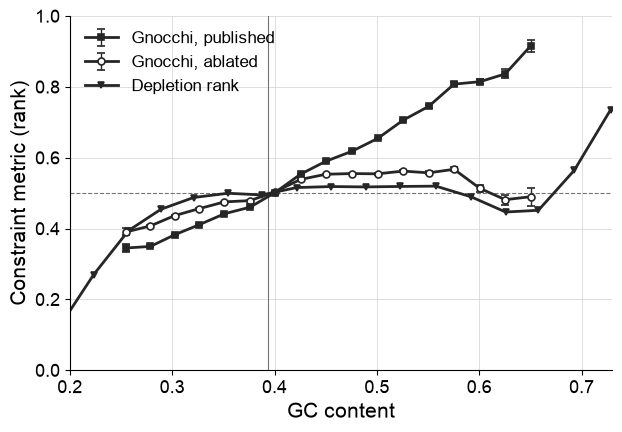

In [4]:
binned_dr = None
if DEPLETION_RANK_BED:
    binned_dr = DR.bin_depletion_rank(DR.load_depletion_rank_windows(DEPLETION_RANK_BED),
                                      n_bins=N_BINS)
else:
    print("DEPLETION_RANK_BED is not set -- panel A gets two curves instead of three.")

curves_a = [
    panels.curve_from_binned(binned_a, "step1", "step1", "Gnocchi, ablated"),
    panels.curve_from_binned(binned_a, "step2", "step2", "Gnocchi, published"),
]
if binned_dr is not None:
    # show_se=False: Halldorsson's windows OVERLAP, so std/sqrt(n) understates the
    # uncertainty and the bar cannot be defended beside two curves of disjoint 1 kb tiles.
    curves_a.append(panels.curve_from_binned(binned_dr, "dr", "dr",
                                             "Depletion rank",
                                             show_se=False))

# DRAW order and LEGEND order are different questions here, so they are stated separately.
# Draw: depletion rank first, i.e. lowest, then the context-only model, then the published
#   score on top -- it is the panel's subject and should not be crossed out where the
#   curves meet.
# Legend: the subject first, the model it is built on top of second, and depletion rank
#   LAST. It is a different metric, on a different window set, binned on its own GC edges
#   -- so it reads as the external comparison rather than as a third Gnocchi curve.
DRAW_ORDER_A = ["dr", "step1", "step2"]
LEGEND_ORDER_A = ["step2", "step1", "dr"]
curves_a.sort(key=lambda c: DRAW_ORDER_A.index(c["key"]))

fig, ax = plt.subplots(figsize=FIGSIZE)
panels.panel_rank_bias(ax, curves_a, gc_mean=gc_mean, xrange=XRANGE, min_n=MIN_N_WINDOWS,
                       legend_order=LEGEND_ORDER_A)
save(fig, "A")

## Panel B — the adjustment Gnocchi applies, decomposed by CpG status

**Per-context expected counts.** Group step 1's sum by trinucleotide context $t$ — the
level $r$ is fit at — writing $c\!\to\!t$ for the classes $c=(t,m)$ sharing context $t$:

$$E_1^{t}(w)=\sum_{c\to t} n_c(w)\,p_c, \qquad E_1(w)=\sum_t E_1^{t}(w).$$

Because $r_t(w)$ carries no methylation index, it comes out of the inner sum, and step 2
is a *reweighting of the same per-context counts*:

$$E_2^{t}(w)=\sum_{c\to t} n_c(w)\,p_c\,r_t(w)=E_1^{t}(w)\,r_t(w),
\qquad E_2(w)=\sum_t E_1^{t}(w)\,r_t(w).$$

**What one window receives.** Dividing,

$$r_{\mathrm{eff}}(w)=\frac{E_2(w)}{E_1(w)}=\sum_t \omega_t(w)\,r_t(w),
\qquad \omega_t(w)=\frac{E_1^{t}(w)}{E_1(w)},\quad \sum_t \omega_t(w)=1,$$

an $E_1$-weighted mean of the per-context $r$. This is why $r_{\mathrm{eff}}$, not any
single $r_t$, is the quantity the score sees: two windows with identical $r_t$ still
receive different adjustments if their context composition differs — and context
composition is precisely what varies with GC.

**What a GC bin receives.** Aggregate a bin $g$ as a **ratio of summed expected counts**:

$$R_{\mathrm{eff}}(g)=\frac{\sum_{w\in g}E_2(w)}{\sum_{w\in g}E_1(w)}
=\sum_{w\in g} W(w)\,r_{\mathrm{eff}}(w),
\qquad W(w)=\frac{E_1(w)}{\sum_{w'\in g}E_1(w')},$$

again an $E_1$-weighted mean, of the window-level $r_{\mathrm{eff}}$ this time. Expected
counts add, so this is the adjustment the bin actually receives, and the weights are not a
separate choice — they fall out of dividing one sum by another. An unweighted mean of
$r_{\mathrm{eff}}(w)$ answers a different question, and would break the CpG decomposition
below, which is an identity only for ratios of sums: bin by bin it reproduces
$R_{\mathrm{eff}}$ to floating point ($\le2\times10^{-16}$), where the unweighted version
misses by up to $4.9\times10^{-3}$ because a window's CpG share and its non-CpG adjustment
are correlated within a bin. The two aggregations agree closely here in any case: Chen et
al.'s QC filter admits only windows with $\ge1{,}000$ possible variants, so $E_1$ spans
just 55.5–345.7, and switching to the unweighted mean would move $R_{\mathrm{eff}}$ by
~0.1% through the GC bulk and 0.79% at worst, in the sparsest low-GC bin. (That
comparison is on the 1,843,559-window reproduction; the narrowed set is a subset of the
same windows, so its $E_1$ span can only be tighter and the two aggregations can only
agree more closely.) **Case carries the level throughout this notebook:** lowercase
$r$ is per context or per window, capital $R$ is the bin-level aggregate, a ratio of
summed expected counts.

**Splitting at CpG.** Let $\mathcal K=\{\mathrm{ACG,CCG,GCG,TCG}\}$ and write
$E_M^{\mathcal K}=\sum_{t\in\mathcal K}E_M^{t}$, $E_M^{\neg\mathcal K}=E_M-E_M^{\mathcal K}$
for $M\in\{1,2\}$. Define each part's own adjustment, and the CpG share of the step-1
counts:

$$R_{\mathrm{CpG}}(g)=\frac{\sum_{w\in g}E_2^{\mathcal K}(w)}{\sum_{w\in g}E_1^{\mathcal K}(w)},
\qquad
R_{\mathrm{non}}(g)=\frac{\sum_{w\in g}E_2^{\neg\mathcal K}(w)}{\sum_{w\in g}E_1^{\neg\mathcal K}(w)},
\qquad
\Pi(g)=\frac{\sum_{w\in g}E_1^{\mathcal K}(w)}{\sum_{w\in g}E_1(w)} .$$

Then, splitting the numerator of $R_{\mathrm{eff}}$ and multiplying each term by 1,

$$R_{\mathrm{eff}}(g)
=\frac{\sum_g E_2^{\mathcal K}+\sum_g E_2^{\neg\mathcal K}}{\sum_g E_1}
=\frac{\sum_g E_1^{\mathcal K}}{\sum_g E_1}\cdot\frac{\sum_g E_2^{\mathcal K}}{\sum_g E_1^{\mathcal K}}
+\frac{\sum_g E_1^{\neg\mathcal K}}{\sum_g E_1}\cdot\frac{\sum_g E_2^{\neg\mathcal K}}{\sum_g E_1^{\neg\mathcal K}}
=\Pi(g)\,R_{\mathrm{CpG}}(g)+\big(1-\Pi(g)\big)\,R_{\mathrm{non}}(g),$$

using only that expected counts add and that $\sum_g E_1^{\neg\mathcal K}/\sum_g E_1=1-\Pi(g)$.
This is an **exact identity**, not a fit, so the panel reads additively.

**Reading the panel.** Its four curves are these symbols, in this order:
$R_{\mathrm{eff}}$ (solid orange diamonds, what Gnocchi applies), $R_{\mathrm{non}}$
(black dashed squares) and $R_{\mathrm{CpG}}$ (black dotted triangles) — the two terms it
decomposes into — and the counterfactual derived next, drawn in $R_{\mathrm{eff}}$'s own
colour and symbol but dashed and hollow, because it *is* $R_{\mathrm{eff}}$ with one term
switched off. The y-axis is $R(g)$ itself, a ratio of summed expected
counts, so 1 means *no adjustment* and the horizontal line at 1 is the null. Since
$R_{\mathrm{eff}}$ is a $\Pi$-weighted average of the other two, it must lie between
them: it tracks $R_{\mathrm{non}}$ closely at low GC, where $\Pi$ is small, and is pulled
down towards $R_{\mathrm{CpG}}\approx1$ as $\Pi$ grows.

**The counterfactual, and what it intervenes on.** The question is how much of
$R_{\mathrm{eff}}$'s rise the CpG contexts could account for on their own. So switch off
the *non-CpG* adjustment — set $r_t\equiv1$ for $t\notin\mathcal K$, which sends
$E_2^{\neg\mathcal K}\!\to\!E_1^{\neg\mathcal K}$ — and change nothing else: the fitted
$r_t$ for $t\in\mathcal K$ stay, the weights $\Pi(g)$ stay. The dashed orange curve is

$$R_{\mathrm{eff}}\big|_{r_t\equiv1,\;t\notin\mathcal K}(g)
=\frac{\sum_g E_2^{\mathcal K}+\sum_g E_1^{\neg\mathcal K}}{\sum_g E_1}
=\Pi(g)\,R_{\mathrm{CpG}}(g)+\big(1-\Pi(g)\big),$$

i.e. **what Gnocchi would apply if it adjusted CpG contexts alone**. It is flat within
0.4% across the whole GC range while $R_{\mathrm{eff}}$ climbs to 1.33, so *none* of the
applied trend survives the removal of the non-CpG term: the GC dependence of what Gnocchi
applies is wholly non-CpG.

Flatness here is a result, not an identity. $\Pi$ reaches **0.26** in the highest bin the
panel draws, so a GC trend in $R_{\mathrm{CpG}}$ would appear in this curve scaled by
$\Pi$, not erased — the curve is flat because $R_{\mathrm{CpG}}$ itself is (0.997–1.014),
which is the next paragraph's subject and is *correct* rather than a failure.

**Where each quantity comes from.** `data._r_eff_components` builds the four per-window
sums, one SQL query, and `data.r_eff_by_gc` does the binning and the divisions:

| symbol | column | built from |
|---|---|---|
| $E_1(w)$ | `e1` | `expected_counts_by_context_methyl_genome_1kb.txt` — published, already summed over all 32 contexts, $r\equiv1$ |
| $E_2(w)$ | `e2` | `refits/expected_counts_by_context_methyl_genome_1kb.{pop}.txt` — the same windows after the refit's $r$ |
| $E_1^{\mathcal K}(w)$ | `e1_cpg` | `expected_counts_per_context_methyl_genome_1kb.txt`, the per-$(w,t)$ export, restricted to $t\in\mathcal K$ and summed |
| $E_2^{\mathcal K}(w)$ | `e2_cpg` | the same rows times `rr` from `refits/rr_by_context.{pop}.txt`, the per-$(w,t)$ adjustment |
| $E_1^{\neg\mathcal K},E_2^{\neg\mathcal K}$ | — | subtraction, `e1 - e1_cpg` and `e2 - e2_cpg` |

The subtraction is why only the CpG slice of the two multi-GB per-context files is ever
joined: an 85M × 85M join becomes 10M × 10M. It also means the identity above mixes two
published files — totals from the summed export, CpG parts from the per-context one — so
it needs them to describe the same counts. They do:
`preconditions/verify_expected_r1.py` regenerates the first from the second genome-wide,
`possible` exactly and `expected` to $4.6\times10^{-5}$ relative.

$R_{\mathrm{eff}}$, $R_{\mathrm{CpG}}$, $R_{\mathrm{non}}$, $\Pi$ and the counterfactual
are then the columns `r_eff`, `r_cpg`, `r_non`, `pi_cpg`, `r_counterfactual`. One further
column, `r_eff_published` $=\sum_g E_2^{\mathrm{pub}}/\sum_g E_1$, replaces the refit's
numerator with Chen et al.'s own published `expected`. It needs no per-context $r$, which
is what makes it a check rather than a restatement: the two agree to $1.7\times10^{-5}$
per bin, median $2.1\times10^{-6}$, and that is what licenses using the refit's
per-context $r$ above — the published pipeline
writes its own only to a local directory, never to the bucket.

**Why $R_{\mathrm{CpG}}\approx1$ is correct, not a failure.** CpG mutability is dominated
by methylation, and $p_c$ is already keyed by methylation level — across methylation 0 to
15 the CpG C>T rate spans **3.0–4.3×** depending on context, the largest single rate
effect in the model, inside one trinucleotide. High-GC CpGs are CpG islands: **92%
hypomethylated in the top GC bin**, against 2.5% in the GC bulk, and their empirical DNM
rate falls from 0.532 in the bulk to 0.283 in that bin (**1.9×**). **Step 1 has already
applied that correction**,
via the covariation of GC content with methylation, so there is nothing left for $r$ to
adjust. (Chen et al. also strip `GC_content`, `CpG_island`, `Nucleosome`, `SINE` and
`met_sperm` from CpG-context models, so those models could not express a GC dependence
even if one were needed.) The GC trend in what Gnocchi applies is therefore entirely
non-CpG — which is where the rest of this figure looks.

reusing /scratch/ucgd/lustre-labs/quinlan/u6018199/gnomad_nc_constraint/fig5/output/r_eff_components.full.parquet


refit validation: max |r_eff(refit) - r_eff(published)| over 20 GC bins = 1.69e-05 (median 2.07e-06)
panel B: mean GC of the 693,270 windows = 0.393


wrote fig5B.neutral.pdf


gc_mid,n,pi_cpg,r_eff,r_cpg,r_non,r_counterfactual
f64,u32,f64,f64,f64,f64,f64
0.255187,700,0.038142,0.965134,0.99703,0.963869,0.999887
0.278779,7325,0.040535,0.962008,0.998051,0.960485,0.999921
0.302413,32130,0.043752,0.965844,0.998199,0.964363,0.999921
0.326197,72298,0.047935,0.971161,0.997447,0.969838,0.999878
0.351088,113017,0.054817,0.97755,0.996966,0.976424,0.999834
…,…,…,…,…,…,…
0.550605,5491,0.153998,1.10537,1.00995,1.122739,1.001532
0.575359,2487,0.176072,1.145198,1.006763,1.174781,1.001191
0.600641,1125,0.203333,1.191122,1.005461,1.238508,1.00111


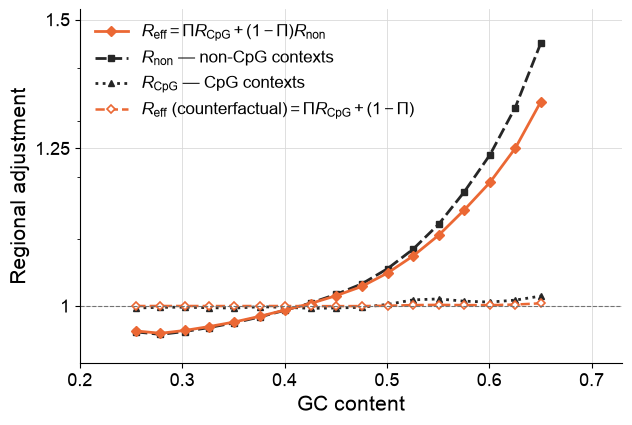

In [5]:
binned_b = D.r_eff_by_gc(df_win, edges, pop="full", cache_dir=CACHE_DIR)

# No mean-GC line on this panel, though A, D and E carry one -- panel_r_eff's docstring
# says why, and it is worth reading before adding one back. The mean is still printed:
# it is the number the caption would quote, and the one that says how far out in the
# tail the divergence at GC 0.6-0.7 happens.
print(f"panel B: mean GC of the {int(binned_b['n'].sum()):,} windows = "
      f"{float((binned_b['n'] * binned_b['gc_mid']).sum() / binned_b['n'].sum()):.3f}")

fig, ax = plt.subplots(figsize=FIGSIZE)
panels.panel_r_eff(ax, binned_b, min_n=MIN_N_WINDOWS, xrange=XRANGE)
save(fig, "B")

binned_b.filter(pl.col("n") >= MIN_N_WINDOWS).select(
    ["gc_mid", "n", "pi_cpg", "r_eff", "r_cpg", "r_non", "r_counterfactual"])

## Panel C — the training set is not the scored population

$r$ is fit on de novo mutations and matched background sites drawn from the **whole
genome**, but applied to — and here evaluated on — the scored population. Panel C
measures how far apart those two drift with GC.

**Two scored populations, and the panel follows whichever is in force.**
`NEUTRAL_WINDOWS_BED` selects between the 1,843,559 windows this repo builds from the
bucket (noncoding + `pass_qc` + autosome/PAR) and McHale et al.'s own 693,270. Either
way the genome splits three ways — **QC-pass noncoding, QC-pass coding, QC-fail** — and
unset, the first of those *is* the scored population, so the stack has three bands. Set,
QC-pass noncoding subdivides into their set and the rest of it, giving a fourth:

$$N(g)=N_{\mathrm{scored}}(g)+N_{\mathrm{other}}(g)
        +N_{\mathrm{coding}}(g)+N_{\mathrm{QC}}(g).$$

Map each non-CpG training site — **both classes, DNMs and background alike** — to its
containing 1 kb tile; the stack plots those fractions per GC bin, and they sum to 1 by
construction. Nothing here re-derives a filter: a site is *scored* exactly when its
window is a row of the analyzed window table, the same table `refit.py` restricts the
training set with and panels A, B and E are evaluated on. So the bands track the
configuration on their own, and a stratum that is empty draws no band and no legend
entry. Between the two configurations QC-fail is identical — it is the windows with no
row in Chen et al.'s table — and what moves is the QC-pass noncoding territory, cut into
the scored and other bands. The coding band can shift a little too, by any window their
file lists that this repo would call coding; the join prints that count.

**The numbers below are from the narrowed run** — `NEUTRAL_WINDOWS_BED` set, which is
what this notebook's panels were built from. So the stack has four bands, its bottom one
is McHale et al.'s 693,270 windows, and the lower row's ratios divide by that band rather
than by QC-pass noncoding as a whole.

**Why both classes.** In a case-control design it is the controls that carry the
covariate distribution, which argues for stacking the background class alone — but that
is an argument about the *design*, not the *fit*. The fit minimizes its loss over the
mixture, so the mixture is the training distribution, and that is what belongs beside the
scored population. Stacking the background class alone barely moves the picture — on the
1,843,559-window reproduction, where this was measured, the QC-fail band runs 0.13 → 0.24
instead of 0.14 → 0.28 — because it outnumbers the DNMs about 12:1; what the DNM class
adds is its own steeper drift, 64% QC-fail at GC 0.64 against the background class's 26%.

**What the two rows are between them.** The upper row is *covariate shift*: $P(x)$ in the
training data is not $P(x)$ in the scored data, and the gap grows with GC. The lower row
is *concept shift*: $P(\mathrm{DNM}\mid x)$ is not the same function in the territory that
drops out. Both are driven by one latent variable — which class of window a site sits in
— and $r$ cannot see it, being fit per trinucleotide context on regional features, none of
which encodes window class. The drifting case-control ratio is not itself the problem:
under case-control sampling the fitted slopes stay consistent whatever the ratio, and
only the intercept shifts. Covariate shift alone would also be survivable, since a
correctly specified model extrapolates. It is the combination — a mis-specified smooth
fit, over a covariate range where the label-generating process is a different one — that
puts a GC slope into $r$.

**The bands above the scored one**, where the labels matter because the mechanism
differs. A *coding* window has a published Gnocchi score; it is this analysis that sets it
aside, following McHale et al.'s noncoding restriction. A *QC-pass putatively nonneutral
noncoding* window is QC-pass and noncoding but outside their set — the rest of that
category, given up in narrowing to it, for an enhancer overlap or one of their interval
exclusions. Its label is the complement of the bottom band's own, *QC-pass putatively
neutral noncoding*, so the two read as one partition of that category rather than as a
named class beside a leftover; *putatively* is load-bearing on both sides, because being
outside a set McHale et al. call putatively neutral is not itself evidence of selection,
and whether these windows differ at all is exactly what the lower row measures.
A *QC-fail* window has no score at all —
Chen et al. dropped it before scoring, keeping only windows with $\ge1{,}000$ possible
variants, $\ge80\%$ of observed variants PASS, and mean coverage 25–35×
(`run_nc_constraint_gnomad_v31_main.py:296`). Since `pass_qc` is `True` on all 1,984,900
rows of the published table, that flag is inert and a QC failure shows up only as an
absent row.

That last band is therefore **not** "no gnomAD coverage", the name it carried here until
measured: of the 587,902 absent autosomal windows, all have their QC inputs on file, and
the PASS rule dominates the failures (417,097, against 19,396 for the coverage band;
`preconditions/verify_qc_filter.py` has the full split, and confirms the filter forwards
too — all 1,984,900 scored windows satisfy all three conditions). It is also a **mixture**
of coding and noncoding, deliberately: 6.9% of these windows overlap coding exons against
7.1% of the QC-pass ones, so QC failure is near-independent of coding status and this is
not a coding band in disguise.

The QC-pass noncoding share of the training set falls from 0.82 in the GC bulk to 0.27 by
GC 0.68, and the scored band — the part of that territory McHale et al. call putatively
neutral — peaks at 0.36 near GC 0.35 and is down to 0.007 over the same distance. So the
model is fit on one population and applied to another, and the two come apart exactly
where panel A's bias is largest.

**The part of the DNM training set that lies outside the scored population has a
different DNM rate** — that is what the lower row measures, and the difference is not
mainly the coding part. Writing $\bar y_s(g)$ for the empirical
non-CpG DNM rate in stratum $s$ and bin $g$, it plots
$\log\!\big[\bar y_s(g)/\bar y_{\mathrm{scored}}(g)\big]$ for each excluded stratum,
against a linear axis, with error bars $\pm\,\mathrm{SE}$ where

$$\mathrm{SE}\Big(\log\frac{\bar y_s}{\bar y_{\mathrm{scored}}}\Big)
=\sqrt{\frac{1-\bar y_s}{k_s}+\frac{1-\bar y_{\mathrm{scored}}}{k_{\mathrm{scored}}}},$$

the delta-method binomial SE with $k$ the DNM count. That SE is symmetric in the log
ratio and in nothing else, so the log is the scale on which the bar drawn is the
interval the data support; it also puts a $2\times$ excess and a $2\times$ deficit
equally far from the reference line. Zero would mean those sites are exchangeable with
the scored ones as far as mutation rate goes. The coding stratum sits there — 0.86–1.00×,
i.e. $|\log|\lesssim0.15$, flat across the whole range — while the QC-failing stratum
runs 1.50–1.63× ($\log = 0.41$–$0.49$) through the GC bulk and **3.39×
($\log = 1.22$) by GC 0.58**. Under the narrowed population the curve to read first is
the putatively nonneutral one, because it is precisely what the narrowing gave up: it is
flat, at 0.94–1.03×, so the narrowing costs sample size and nothing else and the rest of
this figure carries over unchanged. Had it climbed with GC it would have been a third
population change, and would have belonged in the caption beside the other two.

Both rows come from one table of per-stratum counts — this row divides the DNM count by
the site count, the row above takes the site count as a share of its bin. 72,801 of the
non-CpG autosomal DNMs fall in the QC-failing stratum and 17,537 in coding windows,
against 241,487 in QC-pass noncoding ones — 91,906 of those in the scored band, 149,581
in the putatively nonneutral rest of it.

So the steep GC dependence the model learns comes from sequence gnomAD could not call
reliably, which is also where trio DNM calling is least reliable: part of that excess is
plausibly false-positive DNM calls rather than real mutation.

reusing /scratch/ucgd/lustre-labs/quinlan/u6018199/gnomad_nc_constraint/fig5/output/dnm_rate_by_stratum.20bins.ee2148.parquet
training composition: 4,367,225 non-CpG training sites over 20 GC bins


fig5C.neutral: unchanged, left alone
shape: (20, 6)
┌────────┬─────────┬─────────────┬─────────────┬──────────────────────┬────────────────┐
│ gc_mid ┆ n_total ┆ frac_scored ┆ frac_coding ┆ frac_other_noncoding ┆ frac_failed_qc │
│ ---    ┆ ---     ┆ ---         ┆ ---         ┆ ---                  ┆ ---            │
│ f64    ┆ i64     ┆ f64         ┆ f64         ┆ f64                  ┆ f64            │
╞════════╪═════════╪═════════════╪═════════════╪══════════════════════╪════════════════╡
│ 0.2246 ┆ 13254   ┆ 0.003622    ┆ 0.001509    ┆ 0.072506             ┆ 0.922363       │
│ 0.2498 ┆ 13596   ┆ 0.101795    ┆ 0.020815    ┆ 0.796631             ┆ 0.080759       │
│ 0.275  ┆ 75688   ┆ 0.189541    ┆ 0.037285    ┆ 0.703255             ┆ 0.069919       │
│ 0.3002 ┆ 224525  ┆ 0.281866    ┆ 0.051598    ┆ 0.587903             ┆ 0.078633       │
│ 0.3254 ┆ 433603  ┆ 0.341723    ┆ 0.05309     ┆ 0.516085             ┆ 0.089102       │
│ …      ┆ …       ┆ …           ┆ …           ┆ …        

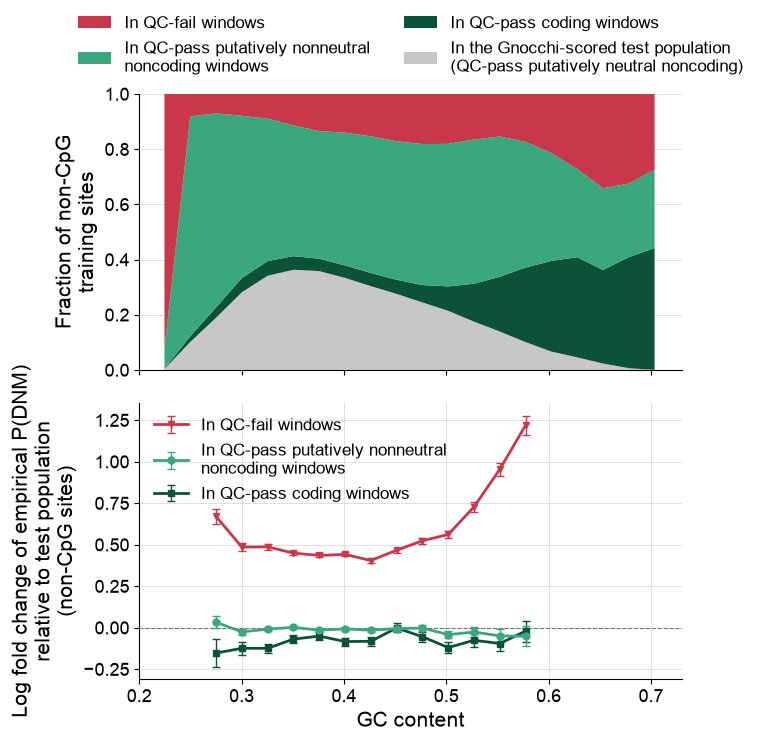

In [6]:
# One table, two rows: `st` carries each stratum's site count (the composition above) and
# its DNM count (the rate below), so the two rows cannot describe different sites.
st = D.dnm_rate_by_stratum(edges, df_win, cache_dir=CACHE_DIR)
comp = D.training_composition(st, edges)
ratios = D.stratum_ratios(st, edges)

fig, (axC1, axC2) = plt.subplots(2, 1, figsize=(FIGSIZE[0], 7.6), sharex=True,
                                 gridspec_kw={"height_ratios": [1, 1], "hspace": 0.12})
# The bottom band's meaning follows NEUTRAL_WINDOWS_BED, but its label would not, so
# name the population in the legend rather than leaving the panel ambiguous on its own.
panels.panel_training_composition(
    axC1, comp, min_n=MIN_N_SITES, xrange=XRANGE, show_xlabel=False,
    scored_note=("QC-pass noncoding" if NEUTRAL_WINDOWS_BED is None
                 else "QC-pass putatively neutral noncoding"))
panels.panel_stratum_ratios(axC2, ratios, xrange=XRANGE)
save(fig, "C")

# Columns from D._STRATA and from whatever stratum_ratios built, rather than a hardcoded
# list: with NEUTRAL_WINDOWS_BED set there is a fourth stratum, and both tables gain
# columns.
print(comp.filter(pl.col("n_total") >= MIN_N_SITES)
          .select(["gc_mid", "n_total"] + [f"frac_{s}" for s in D._STRATA]))
print(ratios.select([c for c in ratios.columns if c != "gc_bin"]))

## Panel D — restricting the training set flattens the DNM rate, and the fit can then track it

**What the two curves of a pair are estimating — one number, by two routes.** Fix a
training population and work over its non-CpG sites only. Write $S_g$ for the sites whose
GC content falls in bin $g$, $y_i\in\{0,1\}$ for site $i$'s DNM label, and $x_i$ for its
feature vector. The quantity the panel is about is the probability that a training site
in that bin carries a DNM,

$$P_g \;\equiv\; \Pr\!\big(y=1 \,\big|\, \mathrm{GC}\in g\big)
\;=\; \mathbb{E}\Big[\,\Pr\!\big(y=1 \mid x\big)\,\Big|\,\mathrm{GC}\in g\Big],$$

the second form by the tower property — and its inner conditional is exactly what each
trinucleotide context's logistic model estimates. The panel plots one estimate of $P_g$
from each form, both plug-in averages over the sites the bin actually holds:

$$\bar y(g)=\frac{1}{|S_g|}\sum_{i\in S_g} y_i \;\approx\; P_g \quad\text{(empirical)},
\qquad
\widehat p(g)=\frac{1}{|S_g|}\sum_{i\in S_g}\hat\pi_i \;\approx\; P_g \quad\text{(fitted)},$$

where $\hat\pi_i=\widehat{\Pr}(y=1\mid x_i)$ is the site's own fitted probability from its
own context's model, evaluated at the **site's** feature vector rather than at the
window-aggregated values the genome-wide apply uses.

The left one is the binomial MLE of $P_g$: unbiased, with standard error
$\sqrt{\bar y(1-\bar y)/|S_g|}$, which is what the error bars carry. The right one is a
Monte-Carlo average of the fitted conditional over the same sites, so it estimates the
same $P_g$ **provided the model is calibrated on that bin's covariate distribution** —
and departs from it when the model is not, which is the whole point of the panel. So
$\widehat p(g)-\bar y(g)$ is a calibration gap conditioned on GC, and each population is
a reliability diagram on itself: *fitted vs empirical within a population* is the
comparison that means something.

**The panel is drawn as two rows over one x axis** — $\bar y(g)$ for both populations on
top, $\widehat p(g)$ for both below — because there are two claims here and they are read
in different directions. The first is about the empirical curves alone (restriction
flattens $\bar y$ and removes its turnover), and it is read *within* the top row, where
those two curves are now adjacent instead of separated by two fitted ones. The second is
the calibration gap above, read *between* the rows at fixed GC; the rows therefore share
one y range, computed over all four curves, so a given vertical distance is the same
interval in either row. A population keeps one symbol and one dash pattern in both rows,
so it reads as a single object down the figure. The axis is linear: normalization puts
every curve through 1 by construction, so that 1 is not a null a departure is being
weighed against, and the ratios the panel is quoted for are read off the curves rather
than off the axis.

Two cautions on what $P_g$ is *not*. It is a probability under the **training**
distribution, not the genome's: every DNM is kept while background sites are sampled at
some rate $s$, which multiplies the odds by $1/s$ and so shifts $\operatorname{logit}P_g$
by $-\log s$ — a constant in $x$, and in particular in GC. Levels are therefore not
comparable **across** populations, whose case-control ratios differ (12.2, 12.2 and 13.4
background sites per DNM), while shapes in $g$ are; each curve is divided by its own
site-weighted mean, leaving shape only. And $g$ enters only as a conditioning event: GC
is one of the 13 candidate regional features, but $\widehat p(g)$ averages whatever the
fit selected for that context, so a pair can come apart in a bin even where GC itself was
never selected.

Two populations:

* **original** — the training set as published;
* **scored** — restricted to the analyzed windows (the intervention).

A third, **size-matched** — the same *number* of sites as *scored*, drawn at random from
the whole genome — is fit and reported, but not drawn here. It is the control that
separates "better-matched population" from "less data", and it lies on top of the
original pair; a curve indistinguishable from one already on the axes costs a series in
each row to say nothing the number cannot. It is reported under panel E, where the
same control is measured on the statistic that matters.

Two things happen at once when the training set is restricted. The **empirical** GC
dependence itself shrinks and becomes monotone — on the original set $P(\mathrm{DNM})$
rises 2.45× and then *collapses* above GC 0.66; on the scored set it rises smoothly by
1.60× with no turnover. And the logistic regression can then actually fit it: on the
original set it misses by 26% and 29% *in opposite directions*, because it is a smooth
monotone surface chasing a curve that turns over, where on the scored set it tracks to
within 6% through GC 0.58. The scored pair's final bin is the exception — 670 sites, and
the fit 28% low there — so the claim is about the GC range the restriction leaves
populated, not about the tail it thins.

This is why $R_{\mathrm{non}}$ in panel B is inflated — the model has partly learned a GC
slope that belongs to sequence outside the scored population.

**Caveat.** This panel measures a *level* error in $P(\mathrm{DNM})$, and levels cancel in
$r$. It diagnoses the fit; it is not itself a measurement of Gnocchi's bias. Panel E is.

full         non-CpG: 4,355,429 sites, 330,559 DNMs, 12.2 background per DNM


scored       non-CpG: 930,417 sites, 70,447 DNMs, 12.2 background per DNM


fig5D.neutral: unchanged, left alone
mean GC of the training sites drawn:  full 0.402,  scored 0.390

full:
 gc_mid       n    n1  mean_pred  empirical_prop
24.9220    9884   726     0.0688          0.0735
28.3489  138720 10030     0.0695          0.0723
31.8810  539742 38988     0.0707          0.0722
35.6131  946096 69084     0.0724          0.0730
39.2875 1013622 74568     0.0745          0.0736
43.0823  777307 57987     0.0766          0.0746
46.9123  485577 37955     0.0795          0.0782
50.7157  243987 19903     0.0837          0.0816
54.5551  116776 10624     0.0895          0.0910
58.4293   51282  5770     0.0986          0.1125
62.2230   20091  2909     0.1120          0.1448
66.0771    7325  1296     0.1304          0.1769
70.0518    3073   449     0.1452          0.1461
73.8314    1237   150     0.1560          0.1213

scored:
 gc_mid      n    n1  mean_pred  empirical_prop
25.0240   1217    85     0.0739          0.0698
28.4438  25759  1899     0.0746          0.0737
31.9

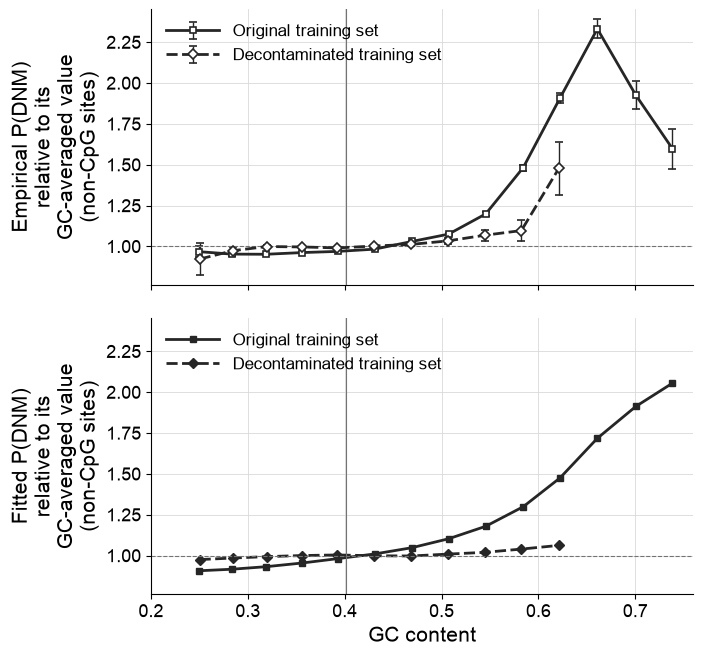

In [7]:
binned_d = D.dnm_probability(("full", "scored"), n_bins=N_BINS, min_n=MIN_N_SITES)

# ONE vertical reference for two populations, so it has to be a population the panel
# names: `full`, the original training set the other is compared against. Both
# site-weighted means are printed below -- if they ever stop agreeing to ~0.01, this
# panel needs two lines or none, because a single one would then be marking a place
# one of its curves is not centred on. In the panel's 0-1 units, hence the /100.
site_mean_gc = lambda b: float((b["n"] * b["gc_mid"]).sum() / b["n"].sum()) / 100.0
gc_mean_d = site_mean_gc(binned_d["full"])

# Two rows over one x axis, as in panel C, and the same figure height: the top holds
# the empirical curves and the bottom the fitted ones. sharex is what lets the two be
# read as one panel; the shared y range that makes the rows comparable is set inside
# panel_dnm_probability_pairs, from both rows' values, rather than here.
fig, (axD1, axD2) = plt.subplots(2, 1, figsize=(FIGSIZE[0], 7.6), sharex=True,
                                 gridspec_kw={"height_ratios": [1, 1], "hspace": 0.12})
panels.panel_dnm_probability_pairs(axD1, axD2, binned_d, min_n=MIN_N_SITES,
                                   normalize=True, gc_mean=gc_mean_d)
save(fig, "D")

print("mean GC of the training sites drawn:  "
      + ",  ".join(f"{pop} {site_mean_gc(b):.3f}" for pop, b in binned_d.items()))
for pop, b in binned_d.items():
    print(f"\n{pop}:")
    print(b[["gc_mid", "n", "n1", "mean_pred", "empirical_prop"]].round(4).to_string(index=False))

## Panel E — refitting $r$ on the scored population removes Gnocchi's bias

Exactly one thing changes relative to the published pipeline: training sites outside the
analyzed window set are dropped. Everything downstream is identical — univariate
Bonferroni selection, standardization, `IncrementalPCA`, L1 logit per context,
genome-wide apply. So panel E is panel A's statistic with a third expected count,
$E_2^{\mathrm{scored}}$, added to the same joint $z$ filter and the same ranking.

Two controls make this a result rather than an anecdote, and both are printed below
rather than plotted (a curve indistinguishable from published Gnocchi is clutter):

* the **full-population refit** through this same code lands on published Gnocchi, so
  "before" and "after" differ by the intervention and not by whose code produced them;
* the **size-matched random refit** also lands on published Gnocchi, so the improvement
  is about *which* sites, not *how many*.

Note the retrained curve is expected to end up *better than* the context-only model, not
merely closer to it: a correct $r$ should repair the context-only model's own droop at
both GC extremes. That is the sense in which this is a positive result and not just the
removal of a defect. On this run it does: mean $|\rho-0.5|$ is 0.168 for published
Gnocchi, 0.046 for the context-only model and **0.026** for the retrained one, against
0.168 for the full-population control and 0.162 for the size-matched one. The first
three of those five are the curves the panel draws, and it carries them in its legend;
the two controls are print-only.

  sanity check: z_step2 vs published z, max |diff| = 0.0 over 693,270 windows
  692,325 windows after joint z filtering
  mean |rank - 0.5|  step1        = 0.046  (over bins with n >= 100)
  mean |rank - 0.5|  step2        = 0.168  (over bins with n >= 100)
  mean |rank - 0.5|  scored       = 0.026  (over bins with n >= 100)
  mean |rank - 0.5|  full_refit   = 0.168  (over bins with n >= 100)
  mean |rank - 0.5|  sizematched  = 0.162  (over bins with n >= 100)


fig5E.neutral: unchanged, left alone


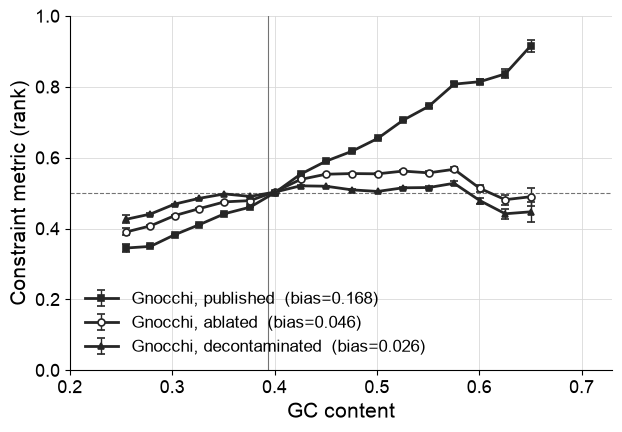

In [8]:
extra = [("scored", D.refit_path("expected", "scored"))]
CONTROLS = [("full_refit", "full"), ("sizematched", "sizematched")]
for label, pop in CONTROLS:
    extra.append((label, D.refit_path("expected", pop)))

df_e, binned_e = D.rank_curves(df_win, extra=extra, min_n=MIN_N_WINDOWS)

# Published Gnocchi first, then the context-only model it is built on, then the retrained
# score -- the order the argument is made in, and the same first-two order as panel A.
curves_e = [
    panels.curve_from_binned(binned_e, "step2", "step2", "Gnocchi, published"),
    panels.curve_from_binned(binned_e, "step1", "step1", "Gnocchi, ablated"),
    panels.curve_from_binned(binned_e, "scored", "scored",
                             "Gnocchi, decontaminated"),
]

fig, ax = plt.subplots(figsize=FIGSIZE)
# Lower left: E carries three labels, each with its bias appended, and at the panel's
# type size that block runs into the published curve if the legend stays top-left as in A.
# show_bias=True: each legend entry carries its own mean |rank - 0.5|, computed over the
# same bins the panel draws. This panel IS the measurement of the bias and of its repair,
# so the three numbers belong on it. Panel A's stay in its caption -- it is the panel that
# poses the problem, and a reader meets the statistic there for the first time.
panels.panel_rank_bias(ax, curves_e, gc_mean=float(df_e["GC_content"].mean()),
                       xrange=XRANGE, min_n=MIN_N_WINDOWS, legend_loc="lower left",
                       show_bias=True)
save(fig, "E")

## Panel F — the same fix, in the units the score is used in

E measures the bias as a **rank**: uniform on $(0,1)$ by construction, so "mean rank returns
to 0.5" is exactly right and tells a user nothing about their own window. F is the same fact
at **Gnocchi $\geq 4$**, Chen et al.'s own cutoff for calling a window constrained — what
fraction of each part of the genome gets called?

**It uses no labels**, being a property of the score and of GC content, which is why it sits
here with the other label-free panels rather than with the discovery analyses that follow.
And it is computed from **panel E's own table and bins**, so E and F are two views of one fix
on one population — E's rank returning to 0.5, F's percentile flattening — rather than two
measurements that happen to agree.

The two scores are matched on **overall** calling rate rather than given a common number:
retraining moves the whole $z$ distribution, so the same numeral is a stricter cutoff for one
of them. The swing *across* GC is a ratio within one score and is untouched by that choice.

**Two reference lines, and they are different kinds of thing.** The vertical one is mean GC —
where the genome actually is, and the same mark panel E carries. The horizontal one is the
matched genome-wide calling rate, and it is **this panel's null**: a score meeting its own
promise would put a fixed $z$ at a fixed percentile of every bin, so it would *be* that line.
It belongs to both curves, the matching pinning both to it, and to neither in particular.

Where each curve meets it is the content. The retrained curve hugs it through the GC bulk and
falls away in the tails, since what is pinned is the window-weighted *mean* rather than any
one bin. The published curve crosses it **well to the GC-rich side of mean GC**, which is the
panel's claim in one glance: its calling rate is near-exponential in GC, so a few GC-rich bins
calling tens of per cent pull the window-weighted mean far above the rate at a typical window.
Equivalently — $z = 4$ is a *typical* cutoff nowhere near the typical window.

  matched calling rate 0.660%, set by step2 at z >= 4
    as published                           z >= 4.000
    decontaminated DNM training set        z >= 3.237


  as published                           calling rate 0.000% - 41.667%  (277x over bins it calls in, and 0% in 1 bin(s))
  decontaminated DNM training set        calling rate 0.000% - 0.693%  (5x over bins it calls in, and 0% in 2 bin(s))


fig5F.neutral: unchanged, left alone
  GC 0.250  n =       700  published   0.000% (100.000th)  retrained   0.143% ( 99.857th)
  GC 0.275  n =     7,319  published   0.150% ( 99.850th)  retrained   0.424% ( 99.576th)
  GC 0.300  n =    32,107  published   0.168% ( 99.832th)  retrained   0.635% ( 99.365th)
  GC 0.325  n =    72,240  published   0.206% ( 99.794th)  retrained   0.684% ( 99.316th)
  GC 0.351  n =   112,907  published   0.240% ( 99.760th)  retrained   0.693% ( 99.307th)
  GC 0.376  n =   128,298  published   0.313% ( 99.687th)  retrained   0.678% ( 99.322th)
  GC 0.401  n =   111,766  published   0.412% ( 99.588th)  retrained   0.691% ( 99.309th)
  GC 0.426  n =    84,501  published   0.624% ( 99.376th)  retrained   0.685% ( 99.315th)
  GC 0.451  n =    60,132  published   0.855% ( 99.145th)  retrained   0.680% ( 99.320th)
  GC 0.477  n =    39,700  published   1.189% ( 98.811th)  retrained   0.562% ( 99.438th)
  GC 0.502  n =    21,880  published   1.869% ( 98.131th)  retr

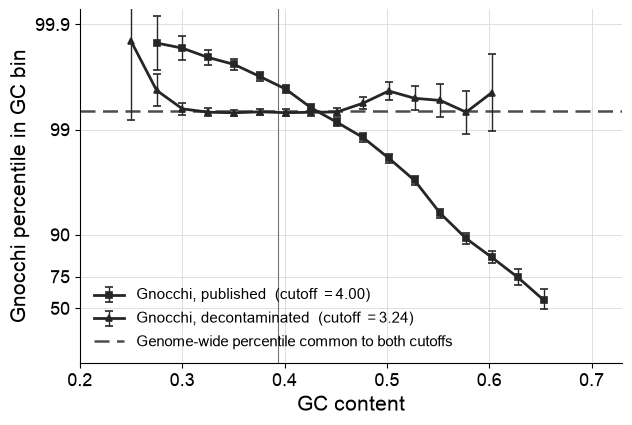

In [9]:
rate_f, thr_f, matched_f = D.calling_rate_by_gc(df_e, threshold=D.GNOCCHI_THRESHOLD,
                                                n_bins=N_BINS, min_n=MIN_N_WINDOWS)

fig, ax = plt.subplots(figsize=FIGSIZE)
# PANEL E'S OWN MEAN, not a freshly computed one: F is drawn on df_e, so the two panels must
# mark the same place on the GC axis or the "one measurement seen twice" pairing is only
# approximately true.
#
# AND THE MATCHED RATE AS A HORIZONTAL LINE, which is the panel's null rather than a summary
# of it: both thresholds were chosen to call that fraction of the whole population, so a score
# whose z meant the same thing everywhere would lie along it. It is the genome-wide value,
# over every window including the bins min_n drops, and NOT a mean over the plotted points.
panels.panel_calling_rate(ax, rate_f, thr_f, xrange=XRANGE,
                          matched_rate=matched_f,
                          gc_mean=float(df_e["GC_content"].mean()))
save(fig, "F")

# THE PER-BIN VALUES THE CAPTION QUOTES. calling_rate_by_gc prints only the min and max
# across bins, and its minimum is 0.000% from bins that call nothing -- true, and not what a
# caption wants for "the most AT-rich bin drawn". Percentile = 100 x (1 - rate) is exactly
# panel F's y axis, so these come off the arithmetic the panel draws, not off the PDF.
pct = lambda r: 100.0 * (1.0 - r)
for row in rate_f.iter_rows(named=True):
    print(f"  GC {row['gc_mid']:.3f}  n = {row['n']:>9,}  "
          f"published {100 * row['rate_step2']:7.3f}% ({pct(row['rate_step2']):7.3f}th)  "
          f"retrained {100 * row['rate_scored']:7.3f}% ({pct(row['rate_scored']):7.3f}th)")
first = rate_f.row(0, named=True)
last = rate_f.row(rate_f.height - 1, named=True)
scored_rates = rate_f["rate_scored"].to_numpy()
print(f"\n  [F-LO] = {100 * first['rate_step2']:.3f}%   "
      f"[F-PCTL-LO] = {pct(first['rate_step2']):.3f}   "
      f"(most AT-rich bin drawn, GC {first['gc_mid']:.3f}, n = {first['n']:,})")
print(f"  [F-HI] = {100 * last['rate_step2']:.3f}%   "
      f"[F-PCTL-HI] = {pct(last['rate_step2']):.3f}   "
      f"(most GC-rich bin drawn, GC {last['gc_mid']:.3f}, n = {last['n']:,})")
print(f"  [F-FLAT] = {100 * scored_rates.min():.3f}% - {100 * scored_rates.max():.3f}% "
      f"over drawn bins (mean {100 * scored_rates.mean():.3f}%)")

## Supporting figure (**Supporting Figure 7** in the manuscript) — why $R_{\mathrm{CpG}}\approx1$ is correct

Panel B asserts that CpG contexts *should* apply no GC-dependent adjustment, because the
effect that would need adjusting has already been applied in step 1. That claim rests on
three measurements which the panel itself does not show, so they get their own figure,
`output/supp_fig7.pdf`:

**A. The size of the methylation effect step 1 absorbs.** $p_c$ is keyed by methylation
level, and for CpG C>T the fitted probability spans **3.0–4.3×** from level 0 to 15 —
within a *single* trinucleotide context, and the largest single rate effect in the model.
The dashed curves are `mu`, the same observable read in a 1,000-genome cohort and rescaled,
which spans 9.7–15.2× over the same range; it is not itself a measured rate, and the
subsection below says what it is. The gap between the curves is the saturation of $p_c$.

**B. High-GC CpGs are CpG islands.** The hypomethylated fraction (level $\leq$ 1) runs
2.5% through the GC bulk and **92% in the top GC bin**, the one bin above GC 0.70; mean
methylation falls from ~6.4 to 0.47 over the same range.

**C. So their DNM rate collapses.** Flat at 0.532 through the bulk, falling to **0.283**
in the top GC bin — a 1.9× fall, tracking B. The two highest bins hold 932 and 1,434
sites; their error bars carry that.

**D. And these contexts are not a rounding error.** $\Pi$, the CpG share of a bin's step-1
expected counts — the same weight panel B's identity
$R_{\mathrm{eff}}=\Pi R_{\mathrm{CpG}}+(1-\Pi)R_{\mathrm{non}}$ uses — rises from
**0.038 to 0.264** across the GC range. So the flatness of panel B's counterfactual is a
measurement and not an artifact of negligible weight: had $R_{\mathrm{CpG}}$ carried a GC
trend, it would have reached the applied multiplier scaled by up to 0.26. This is the
panel that says the A–C mechanism *matters* rather than merely *holds*.

Put together: a large, strongly GC-dependent CpG effect exists, step 1 already applies it,
and the contexts it applies to carry up to 26% of the expected counts. There is nothing
left for $r$ to correct, which is exactly what panel B measures. (Level, not rate: these
are case-control-sampled training sites at ~10:1, so the y-axis of C is not a genome-wide
mutation rate.)

D is binned over **Chen windows** and A–C over **training sites**, the same split the main
figure runs on, so the two do not end in the same place: D's last bin above the 100-window
floor is centred at GC 0.65 against 0.73 for B and C. All four panels share this figure's
0.2–0.8 axis. On the narrowed window set D no longer runs past panel B's own 0.2–0.73
range; that it did — reaching GC 0.75 with $\Pi$ at 0.43, so that the bins carrying the
most CpG weight were exactly the ones the main panel could not show — was a feature of the
1,843,559-window run.

### Panel A's two curves

**The model both curves live in.** Infinite sites plus a genealogy, with $u_c$ for class
$c$'s *true* per-generation mutation rate. Trace the ancestry of
the cohort's $n$ chromosomes back to their common ancestor and add up every generation of
transmission in that tree: $L_n$ generations in all, the genealogy's **total branch
length**. Each one is an independent chance for the site to mutate at rate $u_c$, so the
number of mutations the site accumulates anywhere in the cohort's ancestry is Poisson with
mean $u_c L_n$.

```
                      │      above the MRCA: NOT part of L_n - a mutation
                      │      up there is inherited by the entire cohort,
                      │      so the site looks monomorphic, never counted
                 ┌────┴────┐ <- MRCA
                 │         │
                 │         X     <- one mutation, at rate u_c per generation
                 │         │
              ┌──┴──┐   ┌──┴──┐
              │     │   │     │
             c1    c2  c3    c4     <- the cohort: n sequenced chromosomes
                       ^^    ^^
                       c3 and c4 carry the variant, c1 and c2 do not,
                       so the site is POLYMORPHIC in the cohort

  L_n = total length of every branch below the MRCA, in generations
        (here 4 tip branches + 2 internal ones)
```

Two facts turn the mutation count into the thing the data reports. First, a mutation on any
branch of that tree is inherited by *some but not all* of the cohort's chromosomes —
branches above the common ancestor are not part of $L_n$, and are exactly the ones that
would be invisible — so it shows up as a variant in the cohort. Second, *infinite sites*
says no site is ever hit twice, so no mutation reverts or lands on an allele already
present, and none of them cancel. The site is therefore polymorphic exactly when the count
is non-zero, which has probability $1-\Pr(\text{count}=0)$:

$$P_n(c) \;=\; 1-e^{-u_c L_n}.$$

A rate and a polymorphism probability are therefore two points on one curve, separated
only by $L_n$ — all of the cohort-size dependence sits there, and all of the sequence
biology in $u_c$. The single-genome case is $n=2$, where $L_2=4N_e$ and
$P_2\approx4N_e u_c$ is heterozygosity: $4\cdot2\times10^{4}\cdot1.2\times10^{-8}\approx
9.6\times10^{-4}$, the textbook human per-base value.

**Two cohorts, one parameter** (Peter McHale's reduction, and the cleanest way in). Read
the formula at the two cohort sizes the panel uses. In the 1,000-genome downsample
saturation is weak, so the exponential linearizes:

$$P_{2000}(c) \;\approx\; u_c L_{2000}.$$

Substitute $u_c = P_{2000}(c)/L_{2000}$ into $P_n(c)=1-e^{-u_c L_n}$ and the rate drops
out entirely:

$$\boxed{\;P_n(c) \;\approx\; 1-e^{-k\,P_{2000}(c)},\qquad k=\frac{L_n}{L_{2000}}\;}$$

One parameter, and it is not a mutation rate: it is the **ratio of the two cohorts'
genealogies**. Everything class-specific — context, methylation, the whole point of the
table — has cancelled, and with it any need for a notion of an absolute mutation rate:
the two cohorts calibrate each other.

**The two curves are that formula read at the two cohort sizes.** The **solid** curve is
$P_n(c)$ itself at $n=152{,}312$ chromosomes — $p_c$ = `fitted_po`, the probability a site
of that class is polymorphic in the 76,156-genome call set, and the operative output of step 1
(`expected = possible × fitted_po`). The **dashed** curve is Chen et al.'s `mu` column,
which despite its name and its units is $P_{2000}(c)$ times one global constant; the panel
divides each curve by its own methylation-0 value, so that constant cancels exactly and the
dashed curve *is* $P_{2000}$, normalized. Saturated end and unsaturated end of the same
relation, in other words — which is why the solid curve is so much the flatter of the two.
Chen et al. plot the relation itself in their **Extended Data Fig. 1a**: proportion observed
in 76,156 genomes against `mu`, "exponentially correlated" in their caption, fitted as
$y=1-\exp(-1.88\times10^{7}x-7.32\times10^{-5})$ with $R^2=0.999$ — the boxed relation, in
their units.

*"Unsaturated" is relative.* At 1,000 genomes the median row is 0.75% polymorphic, but the
top of the dashed curve — ACG C>T at methylation 15 — is **27.6%**. Read as a Poisson rate,
$-\log(1-P_{2000})$, that context's span against methylation 0 is 13.2× rather than the
11.4× the raw proportion gives, so the dashed curve understates the true spread as well and
the solid curve's compression is a lower bound.

**What the gap does and does not imply.** Saturation is not an error in Chen et al.'s
model. The expected counts built from $p_c$ are compared against observed *polymorphism*
counts, which saturate identically, so it cancels — the same cancellation that makes a
level error invisible in $r$.

CpG C>T, methylation 0 -> 15:  fitted_po spans 3.0-4.3x, mu spans 9.7-15.2x
reusing /scratch/ucgd/lustre-labs/quinlan/u6018199/gnomad_nc_constraint/fig5/output/cpg_methylation_by_gc.20bins.c1533c.parquet


supp_fig7.neutral: unchanged, left alone


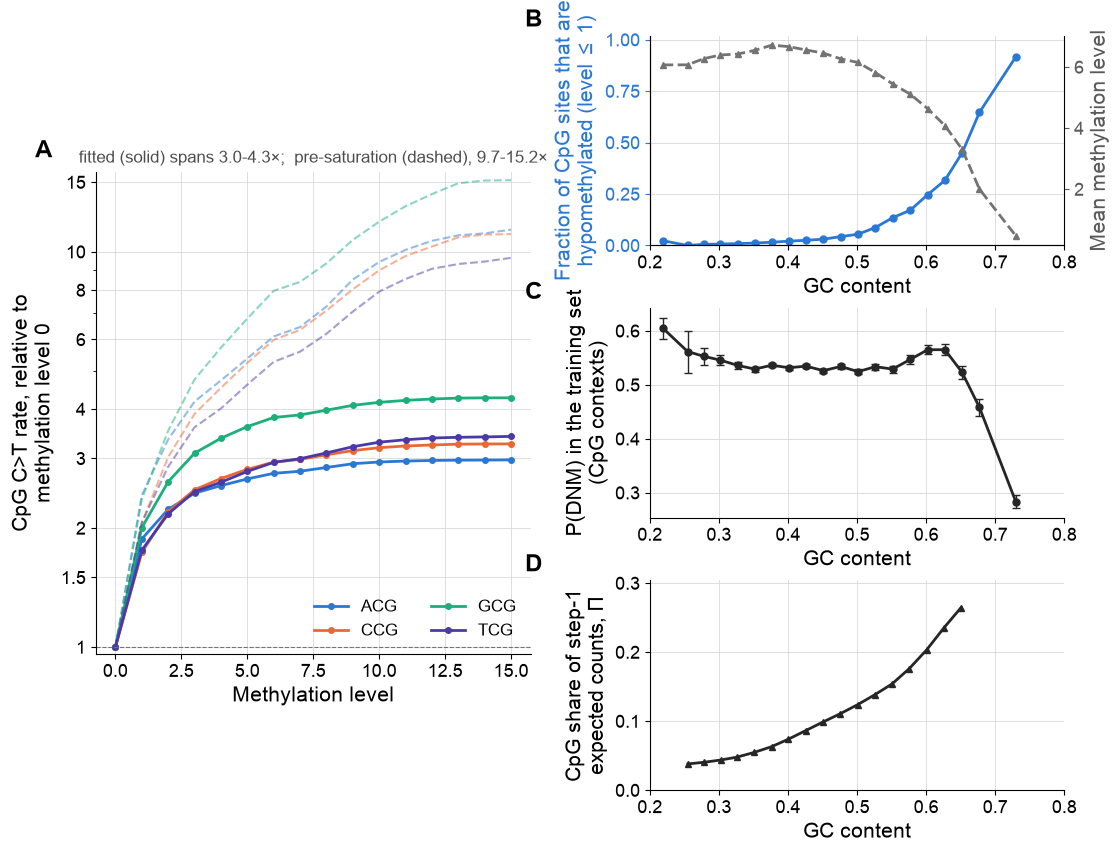

In [10]:
ct = D.cpg_rate_by_methyl(cache_dir=CACHE_DIR)
cpg = D.cpg_methylation_by_gc(edges, cache_dir=CACHE_DIR)

# A ON THE LEFT, B-D STACKED ON THE RIGHT. A is the one panel whose abscissa is not GC
# content -- it is methylation level -- so standing it beside the others rather than above
# them stops the figure reading as one column against one x-axis, and puts the three GC
# panels together, which is the order B -> C -> D is argued in. It also takes the figure
# from 7 x 16.5 in, a column no page holds, to a landscape page.
#
# Six rows so A can span the middle four: it then sits vertically centred against the
# three on the right at close to its own aspect, where spanning all six would stretch a
# saturation curve over the full height of the page.
fig = plt.figure(figsize=(12.5, 9.8))
gs = fig.add_gridspec(6, 2, width_ratios=[1.05, 1], wspace=0.28, hspace=0.85)
axA = fig.add_subplot(gs[1:5, 0])
axB, axC, axD = (fig.add_subplot(gs[i:i + 2, 1]) for i in (0, 2, 4))

panels.panel_cpg_methylation_effect(axA, ct)
# MIN_N_CPG, not MIN_N_SITES: the top two GC bins (n = 932 and 1,434) carry the claim,
# and their error bars show how thin they are. Quote numbers from this same subset.
#
# EVERY PANEL LABELS ITS OWN X-AXIS, hence no show_xlabel=False here. Nothing here shares
# an axis: A's abscissa is methylation level, and B-D, though stacked, are three separate
# axes with their own ticks and a gap between them rather than one sharex column, so each
# is read -- and cited -- on its own. The suppression that is right in panel C, where two
# sharex axes ARE one plot, would here leave two panels whose x quantity is named nowhere.
panels.panel_cpg_hypomethylation(axB, cpg, min_n=MIN_N_CPG)
panels.panel_cpg_dnm_rate(axC, cpg, min_n=MIN_N_CPG)
# binned_b and MIN_N_WINDOWS, not cpg/MIN_N_CPG: Pi is a per-window weight, and this is
# the same table and the same bin floor panel B decomposes, so the curve here IS the
# weight in that identity rather than a second estimate of it.
panels.panel_cpg_expected_share(axD, binned_b, min_n=MIN_N_WINDOWS)
# Two calls, two offsets: label_panels places the letter in AXES coordinates, so the -0.1
# that clears A's ylabel lands on top of the narrower right-hand panels' ylabels.
panels.label_panels((axA,), ("A",))
panels.label_panels((axB, axC, axD), ("B", "C", "D"), x=-0.26)

supp_name = f"supp_fig7{config.WINDOW_SET_SUFFIX}"
written = resave_ai.save_panel(fig, os.path.join(OUTPUT_DIR, supp_name))
print(f"wrote {', '.join(os.path.basename(p) for p in written)}" if written
      else f"{supp_name}: unchanged, left alone")

In [11]:
shown = cpg.filter(pl.col("n") >= MIN_N_CPG)
bulk = shown.filter((pl.col("gc_pct") > 35) & (pl.col("gc_pct") < 50))
p_bulk = float(np.average(bulk["p"], weights=bulk["n"]))
top = shown.sort("gc_pct")[-1]
print(f"Supporting Figure 7B: hypomethylated fraction "
      f"{float(np.average(bulk['frac_hypomethylated'], weights=bulk['n'])):.3f} in the "
      f"GC bulk -> {shown.filter(pl.col('gc_pct') > 70)['frac_hypomethylated'].min():.2f}"
      f"-{shown['frac_hypomethylated'].max():.2f} above GC 0.70")
print(f"Supporting Figure 7C: DNM rate {p_bulk:.3f} in the GC bulk -> "
      f"{float(top['p'][0]):.3f} in the top GC bin "
      f"({p_bulk / float(top['p'][0]):.1f}x lower)")
pi = binned_b.filter(pl.col("n") >= MIN_N_WINDOWS)["pi_cpg"]
print(f"Supporting Figure 7D: CpG share of step-1 expected counts "
      f"{pi.min():.3f} -> {pi.max():.3f}")
print(shown.select(["gc_pct", "n", "mean_methyl", "frac_hypomethylated", "p"]))

Supporting Figure 7B: hypomethylated fraction 0.025 in the GC bulk -> 0.92-0.92 above GC 0.70
Supporting Figure 7C: DNM rate 0.532 in the GC bulk -> 0.283 in the top GC bin (1.9x lower)
Supporting Figure 7D: CpG share of step-1 expected counts 0.038 -> 0.264
shape: (20, 5)
┌───────────┬──────┬─────────────┬─────────────────────┬──────────┐
│ gc_pct    ┆ n    ┆ mean_methyl ┆ frac_hypomethylated ┆ p        │
│ ---       ┆ ---  ┆ ---         ┆ ---                 ┆ ---      │
│ f64       ┆ i64  ┆ f64         ┆ f64                 ┆ f64      │
╞═══════════╪══════╪═════════════╪═════════════════════╪══════════╡
│ 21.894737 ┆ 610  ┆ 6.070492    ┆ 0.022951            ┆ 0.604918 │
│ 25.46358  ┆ 162  ┆ 6.074074    ┆ 0.0                 ┆ 0.561728 │
│ 27.825476 ┆ 946  ┆ 6.276956    ┆ 0.005285            ┆ 0.552854 │
│ 30.224383 ┆ 3203 ┆ 6.395879    ┆ 0.006869            ┆ 0.545738 │
│ 32.6891   ┆ 7211 ┆ 6.4256      ┆ 0.008737            ┆ 0.536125 │
│ …         ┆ …    ┆ …           ┆ …          

## Supporting Figure 8 — what Fig. 5F's fix does to *discovery*

Fig. 5E and 5F say the retrained score is no longer GC-biased. Neither says whether the biased
score was nevertheless the better **detector**, since bias and signal-to-noise act on discovery
jointly (McHale et al.'s Fig. 3) and only one of them changed. This figure is that test, built
as their **Fig. 4A/B**: call a window constrained when Gnocchi $z$ exceeds a threshold, label it
constrained if it overlaps a GeneHancer enhancer, and read performance *within each GC bin*,
with two Gnocchi variants in place of their four metrics.

*Bare letters below mean this figure's panels; Fig. 5's are written 5A–5F.*

| | Asks | Quantity | Operating point |
|---|---|---|---|
| **A** | *Published:* where do its calls **go**, and is a call worth more there? | recall and $\mathrm{LR}^{+}$ per bin | one global cutoff |
| **B** | *Retrained:* the same two questions, same axes | recall and $\mathrm{LR}^{+}$ per bin | one global cutoff |
| **C** | Does it change ranking *at all*? | auPRC / positive-class fraction | none |
| **D**, **E**, **F** | What cutoff would each score need to call the top **99%**, **50%**, **1%** of every bin? | per-bin threshold | — |
| **G**, **H**, **I** | Does debiasing help at each of those three depths? | $\mathrm{LR}^{+}$ ratio per bin | rate matched **within** each bin |

**G, H and I are one comparison at three points, not three comparisons.** A call is $z > t$ and
a hit is an enhancer in all three; only the fraction of the bin called changes, $99\% \to 50\%
\to 1\%$ down the stack (`data.LAX_CALL_RATES`). Since C integrates over the *whole* recall
axis, reading one comparison at three points along it says **where** the two scores differ,
which no single threshold-free number can. D, E and F are the cutoffs that construction
requires, row-aligned with G, H and I and using no labels at all — three quantiles of each
score's own distribution, of which **E is a calibration check**: the cutoff calling the top 50%
of a bin *is* that bin's median $z$, and a score whose null is $N(0,1)$ on these windows has its
median near $0$ everywhere.

**A and B are one panel per score, and the comparison is inside each** — two metrics on one
score, recall on a log left axis and $\mathrm{LR}^{+}$ on a linear right axis, asking whether
that score sends its calls where a call is worth anything. Both share both y ranges. G, H and I
are where the two scores meet.

**$\mathrm{LR}^{+}$ and not lift, everywhere the reading is across bins.** Lift is
$\text{precision}/r$ and $r$ climbs $7.7\times$ here, so lift carries a ceiling of $1/r$ falling
$12.0 \to 1.57$. The two do not merely differ in size: on these very rows lift falls
$1.80 \to 1.12$ while skill *rises* $0.073 \to 0.218$, so **dividing by a function of the
prevalence is not a prevalence correction** and the choice decides the sign of the trend.
$\mathrm{LR}^{+} = P(\text{call} \mid Y{=}1)/P(\text{call} \mid Y{=}0)$ conditions on the true
class on both sides, so $r$ cancels outright. Lift survives only as the within-bin translation a
caption quotes.

**Two kinds of operating point, and the difference is the figure's spine.** A and B apply one
fixed global cutoff per score — published at $z \ge 4$, retrained at $z \ge 3.140$, the value
calling the same 1.00% of the population — and let each *bin*'s share fall where it may. **That
freedom is the bias**; imposing a per-bin rate there would delete what A and B measure. D–I
impose it instead, which is what isolates ranking from threshold placement. So $z = 4$ appears
only once here, as A's actual cutoff; Fig. 5F keeps it unmatched and label-free, the third role.

**Error bars differ accordingly.** C, G, H and I carry a 95% paired-bootstrap interval on the
retrained curve relative to published — bars on one curve, not two, because independent
intervals would describe the uncertainty of each *level* when the question is the *gap*, and
would be wider, the two scores being columns of one table. **What makes it paired** is that each
replicate draws ONE index vector for the bin and scores *both* models on it, so the variability
in which windows a bin happens to contain cancels in the difference; thresholds are held fixed
across replicates, being quantiles of $\sim\!10^6$ windows. A and B carry each level's own Wilson
interval instead: their scores sit at different operating points by construction, so a gap
*between* those two panels is the confound G–I remove, and their claim is each curve's shape. D,
E and F have no bars — a quantile of a million windows has none worth drawing.

***Lax* is McHale et al.'s word, and it anticipates its opposite.** GeneHancer covers 18.4% of
the noncoding genome while perhaps 4.51% is under human-specific selection, so the lax set buys
size at the cost of label confidence; 30.9% of windows here are positive. Their **stringent**
set is deliberately not built (CLAUDE.md carries the decision and the power argument). The
population is this notebook's own with one filter dropped — `keep_enhancer_windows=True`, so
enhancer-overlapping windows are kept as the positive class. Note the asymmetry: the `scored`
refit is **fit** on the neutral windows alone and **evaluated** here on both halves.

> **WHICH NUMBERS ARE REAL.** A, B, C, I and D's and F's cutoffs are from the committed run.
> **E, G and H have never been run** — they were added on 2026-09-11, when the figure stopped
> asking about the left tail (see the note below). Two further traps in the older numbers: I
> moved from lift to the $\mathrm{LR}^{+}$ odds ratio on 2026-09-08, so the old lift figures
> (+33.3, +4.0, +4.2, +10.8, +2.2 per cent) are a *different statistic* and must never be
> carried over; and every number once attached to a bottom-1% panel measured the retired
> hypothesis.

### A and B: the same budget of calls, sent somewhere else

**Published Gnocchi's two curves run in opposite directions** — recall climbing $45.7\times$
with GC while $\mathrm{LR}^{+}$ falls steadily — so **the score calls most where a call is worth
least**. The retrained score's recall is flat instead, on the same fixed budget of 10,051 calls
(1.00% of the 1,003,036 windows drawn).

| GC bin | A: recall | A: $\mathrm{LR}^{+}$ | A: calls | B: recall | B: $\mathrm{LR}^{+}$ | B: calls |
|---|---|---|---|---|---|---|
| (0.20, 0.30] | 0.33% | 2.06 | 38 | 2.03% | 3.11 | 168 |
| (0.30, 0.40] | 0.52% | 1.94 | 1,630 | 1.60% | 1.91 | 5,050 |
| (0.40, 0.50] | 1.24% | 1.57 | 3,933 | 1.39% | 1.69 | 4,228 |
| (0.50, 0.55] | 4.01% | 1.44 | 1,832 | 1.07% | 1.80 | 451 |
| (0.55, 0.80] | 15.07% | 1.25 | 2,618 | 0.93% | 1.50 | 154 |

B's $\mathrm{LR}^{+}$ still declines, $3.11 \to 1.50$, and **that residual is C's
signal-to-noise, not a remnant of the bias** — a reader who takes B as "still not fixed" has
read C's quantity off B's axes.

**Recall is redistributed across GC, not lost**, and the per-bin figures must never be quoted
one bin at a time. The budget being fixed, debiasing spends elsewhere rather than less:
published puts **2,618** calls where its $\mathrm{LR}^{+}$ is **1.25** and **38** where it is
**2.06**; the retrained score cuts the first to **154** and raises the second to **168**. So
"debiasing costs recall" is a high-GC half-truth.

*Do not turn the two panels into one comparison.* Retrained $\mathrm{LR}^{+}$ is higher in four
bins of five and marginally lower in the second (1.91 against 1.94) — but the scores are at
different operating points in every bin, which is the confound G–I remove. And in absolute
positives found the reallocation costs, 5,485 against 4,396, because the base rate itself climbs
$7.7\times$; whether that is a real loss is not a question a GC-confounded truth set can answer.

### C: nearly blind to the bias, and that is the finding

The two curves nearly coincide, and that is not a null result — auPRC *within* a GC bin cannot
see the bias, because a GC-dependent bias is nearly a common shift on every window in a narrow
bin, and a common shift cannot change a ranking. So the steep decline of auPRC with GC
(published $1.518 \to 1.199$, retrained $1.554 \to 1.298$) **survives debiasing intact**, and
what remains is **signal-to-noise** — McHale et al.'s conjecture, now measured. The decline is
not the score sitting too low in GC-rich sequence; it is the observed-against-expected
comparison carrying less constraint signal there relative to its own noise. It is named **by
elimination**: this figure shows the decline survives, it does not measure the mechanism.

**C comes third, and it is the figure's hinge.** A and B say where each score spends its calls;
C then says that over the whole recall axis debiasing buys essentially nothing — pooled 1.321
against 1.341, with the one significant bin *negative*. G, H and I exist because that verdict is
an average: a wash over all thresholds is consistent with a gain at one depth and a loss at
another, which is exactly what two crossing PR curves would produce, and only a comparison read
at more than one depth can say which.

Two guards. Its *direction*: the claim rests on the decline **surviving**, not on the curves
agreeing — their agreement is close to guaranteed by the binning, since within 5–10 GC points
the adjustment is nearly a constant offset, so it checks the bin edges rather than evidencing
anything about the decline. Its *scope*: the claim is about the GC **slope** of discriminative
power, not its level, which debiasing does move. The bars matter because the panel's most
eye-catching feature is the top-bin gap (1.199 against 1.298 on 6,217 windows) — exactly the
difference that does not survive.

**I and C do not contradict each other.** auPRC integrates over the *whole* recall axis; a
threshold statistic at 1% probes only the top, and the two scores' PR curves cross. Both are
right, weighting the recall axis differently — which makes **auPRC the wrong summary for a
constraint score**, since the top ~1% is the entire use case. It is still the right *question*
to have asked, because it is what forces G, H and I: if the gain at the top is real and the
average is flat, the offset has to sit somewhere further down the ranking.

### What carries the signal-to-noise claim, and why only C can close it

**For the Discussion.** Three curves carry it, and they are not equally strong.

**A and B corroborate it legitimately.** $\mathrm{LR}^{+}$ falls with GC for *both* scores —
$2.06 \to 1.25$ published, $3.11 \to 1.50$ retrained (not monotonically: 3.11, 1.91, 1.69, 1.80,
1.50) — and since it conditions on the true class on both sides, the $7.7\times$ prevalence
climb cancels exactly. The decline is real, in the units an analyst applying a cutoff
experiences, and it survives the correction.

**What they cannot rule out is that it is specific to the top ~1%.** Both are read at a single
operating point, and nothing in a fixed-threshold panel distinguishes a ranking that carries
less signal in GC-rich sequence *throughout* from one where only its tail does.

**B is the stronger of the two.** The panels fix one $z$, not one *depth*: published calls 0.17%
of the most AT-rich bin and 13.97% of the most GC-rich, an 82-fold swing, so A compares one
bin's extreme tail against another's top seventh. The retrained score's rates run 0.77–1.04%,
near enough depth-matched. *Do not turn that into a claim about the direction of the confound.*
The tempting story — reading deeper lowers enrichment, so A's decline is exaggerated — is not
supported: loosening the global cutoff from 1% to 10%, published lift runs 1.08, 1.08, 1.07 in
the top GC bin and 1.90, 2.12, 2.17 in the most AT-rich, flat then *rising*. That is lift rather
than $\mathrm{LR}^{+}$ and a global rather than per-bin rate, so it is not decisive either way.
A is simply not like-for-like across bins.

**C is the only panel with no operating point at all**, so no cutoff placement can be generating
its decline. That is why the claim is cited to C, with B as evidence that it is not an artefact
of a statistic nobody uses.

*The three are not independent measurements* — one ranking, one truth set, and a defect in the
truth set moves all three. They are independent only in **where on the ranking they look**: C
everywhere, B at a near-constant top 1%, A at a depth that itself varies 82-fold.

### D, E and F: the cutoffs each score would need, bin by bin

To call the same fraction of every GC bin, what threshold would each score require? Published
Gnocchi answers with a **curve** at all three depths and the retrained score with something
close to a **constant** — which is the point of stacking them: a bias that moves the top 1%
cutoff, the median and the top 99% cutoff alike is a shift of the **whole** score within a bin,
not a stretched tail. At the top 1%, published climbs **2.83 → 6.38** (2.26-fold) against
**3.01 → 3.16** (1.05-fold); in the left tail it runs **−5.67, −6.04, −5.03, −4.14, −2.98**,
rising 3.05 in $z$ over its last four bins, against a retrained curve staying within **0.79** of
itself. Like Fig. 5F and unlike everything else here, **these use no labels at all**.

F is Fig. 5F's inverse, not its repetition: 5F fixes the threshold and reads the calling rate, F
fixes the rate and reads the threshold, each natural for a different reader. The three sit here
rather than beside 5F because they are **G, H and I's x-axes made visible** — the gains are
measured at exactly these thresholds, so a shared x axis connects a cutoff to what it buys, and
a reader who suspects the matching of being artificial can see how far it had to reach.

### I: the top of the ranking, where the score is used

Fig. 5F *is* the statement that the two scores call very different fractions of each bin — 14%
against 0.8% at the top — so comparing them at a common cutoff compares two operating points. I
matches the calling rate **within** each bin, so neither is read at a different place on its own
curve.

**I is a ratio, not two levels.** Level curves invite a reader to compare each curve with
*itself* across GC — A and B's job — when the only question here is whether retraining helps
*in* a bin. **And it is the odds ratio**: within a bin the base rate cancels from either
measure, so the lift ratio is exactly the precision ratio, but a fold increase in precision is
bounded by $1/\text{precision}_{\text{published}}$, a ceiling falling about $14\times$ across
these bins, so a $+2\%$ in the GC-rich bins and a $+33\%$ in the AT-poor ones are not measured on
the same ruler. Since $\text{odds}(\text{precision}) = \mathrm{LR}^{+} \times \text{odds}(r)$,

$$\frac{\text{odds}(p_{\text{scored}})}{\text{odds}(p_{\text{published}})} = \frac{\mathrm{LR}^{+}_{\text{scored}}}{\mathrm{LR}^{+}_{\text{published}}}$$

and the prevalence cancels exactly, making the curve comparable bin to bin.

**The gaps strengthen rather than collapse**: **+37.7%, +6.3%, +8.5%, +33.0%** and **+8.4%** from
the lowest GC bin to the highest, with **four** of five clear of 1.0. Quote the middle bins; the
AT-poor gain is largest but rests on 219 called windows per score.

*I describes a score nobody applies, deliberately.* **I says what the score CONTAINS; Fig. 5F
says what happens when it is USED; A and B are the bridge.** The analyst-legible form is the
per-bin **precision** ratio, which the matched rate makes a rescaling of I's own rows: the
retrained score's calls are correct **1.30 times** as often as published's in the most AT-rich
bin and **1.02 times** as often in the most GC-rich. Those are *precision* ratios and therefore
smaller than the odds ratios I plots; quoting one for the other is the easiest error to make
with this panel.

### The pooled numbers fall, and that is not evidence against the correction

At the same 10,051-call budget, published finds 5,485 positives and the retrained score 4,396
(precision $0.546 \to 0.437$). That cost is real, and it is not evidence against the correction,
because the quantity it is measured in is the one the correction removes. This truth set's
positives are GC-rich — the base rate climbs from 8.3% in the lowest GC bin to 63.9% in the
highest — and published Gnocchi is precisely the score that calls GC-rich sequence constrained.
Its pooled advantage is therefore its GC bias working as an enhancer detector, so judging the
debiasing by this table is circular: a GC-biased score wins here *by being biased*. Which is why
every panel is computed WITHIN a GC bin.

The same skew cuts the other way once conditioned, and that is the form worth stating. Positives
stay enriched at the high-GC end of *every* bin, so even within a bin the truth set hands
published a tailwind — and the retrained score wins in all five bins anyway. **I is
conservative, not flattered.**

**What Fig. 5F and this figure establish together:**

> Debiasing removes the GC dependence of how often Gnocchi fires, and with it the GC dependence
> of how much it finds. It leaves untouched the GC dependence of how much a hit is worth — that
> is signal-to-noise, and it is a property of the data.

**A and B** add that the calls taken out of GC-rich sequence go back where a call is worth
roughly twice as much, at a fixed budget; **I**, that it also raises what a hit is worth at the
top of the ranking, without flattening that value's GC dependence. Whether it costs anything
further down is **G and H's question, and they have not been run**.

In [12]:
# One call: labelled table -> GC bins -> class balancing -> precision-recall curves.
# pr_curves() reads config.NEUTRAL_WINDOWS_BED itself, for both the population and the
# lax truth set's label -- one join supplies both, which is what keeps this figure's
# windows identical to Fig. 5E's apart from the enhancer-overlapping half.
curves_s8 = D.pr_curves(truth_set="lax", seed=0) if NEUTRAL_WINDOWS_BED else None
if curves_s8 is None:
    print("NEUTRAL_WINDOWS_BED is not set -- Supporting Figure 8 skipped.\n"
          "The lax truth set is the GeneHancer enhancer flag in that file, which is "
          "licensed and\nnot derivable from the public bucket, so there is nothing to "
          "classify against.")

McHale et al. window file: 1,003,227 rows, 309,957 (30.9%) overlapping an enhancer
McHale-window join (enhancer windows KEPT): 1,984,900 scored windows -> 1,003,227 labelled, 309,957 positive (30.9%)
decontaminated expected counts: /scratch/ucgd/lustre-labs/quinlan/u6018199/gnomad_nc_constraint/refits/expected_counts_by_context_methyl_genome_1kb.scored.neutral.txt


  sanity check: z_published vs published z, max |diff| = 0.0 over 1,003,227 windows
evaluated: 1,003,037 windows, 309,908 positive (30.9%)
class balancing: positive fraction pegged to 0.0833 in every GC bin; 1,003,036 -> 756,106 windows
mean GC of the evaluated windows: 0.394


  Gnocchi (published): GC (0.6, 0.65] dropped, n = 1,086 < 4,000
  Gnocchi (published): GC (0.65, 0.7] dropped, n = 65 < 4,000
  Gnocchi (published): GC (0.7, 0.8] dropped, n = 2 < 4,000
  Gnocchi (published): auPRC/r = 1.321 pooled; (0.20,0.30]=1.518, (0.30,0.40]=1.385, (0.40,0.50]=1.292, (0.50,0.55]=1.284, (0.55,0.60]=1.199


  Gnocchi (decontaminated training set): GC (0.6, 0.65] dropped, n = 1,086 < 4,000
  Gnocchi (decontaminated training set): GC (0.65, 0.7] dropped, n = 65 < 4,000
  Gnocchi (decontaminated training set): GC (0.7, 0.8] dropped, n = 2 < 4,000
  Gnocchi (decontaminated training set): auPRC/r = 1.341 pooled; (0.20,0.30]=1.554, (0.30,0.40]=1.383, (0.40,0.50]=1.271, (0.50,0.55]=1.296, (0.55,0.60]=1.298


In [13]:
# PANEL C's ERROR BARS: the paired bootstrap. Its own cell because it is the one slow step
# in this figure -- ~500 resamples x one precision-recall pass per drawn bin, twice -- and
# because re-running it should not mean rebuilding the other six panels. A couple of
# minutes.
# ON PANEL C's OWN BINS AND BALANCING, because its output is drawn as C's error bars and
# an interval computed on a different population would belong to a different statistic
# than the markers it sits on. That is why gc_bins/min_n/balance are passed explicitly
# here and defaulted everywhere else.
deltas_s8 = D.pr_curve_deltas(truth_set="lax", seed=0, n_bootstrap=500,
                              gc_bins=D.LAX_GC_BINS, min_n=D.LAX_MIN_BIN_WINDOWS,
                              balance=True) if NEUTRAL_WINDOWS_BED else None

McHale et al. window file: 1,003,227 rows, 309,957 (30.9%) overlapping an enhancer
McHale-window join (enhancer windows KEPT): 1,984,900 scored windows -> 1,003,227 labelled, 309,957 positive (30.9%)
decontaminated expected counts: /scratch/ucgd/lustre-labs/quinlan/u6018199/gnomad_nc_constraint/refits/expected_counts_by_context_methyl_genome_1kb.scored.neutral.txt


  sanity check: z_published vs published z, max |diff| = 0.0 over 1,003,227 windows
evaluated: 1,003,037 windows, 309,908 positive (30.9%)
class balancing: positive fraction pegged to 0.0833 in every GC bin; 1,003,036 -> 756,106 windows


  GC (0.20, 0.30]  n =    21,862  pos =    1,821  delta =  +2.33%  [ -0.39,  +4.59]  P(delta > 0) = 0.950


  GC (0.30, 0.40]  n =   427,169  pos =   35,581  delta =  -0.14%  [ -0.67,  +0.34]  P(delta > 0) = 0.266


  GC (0.40, 0.50]  n =   272,867  pos =   22,728  delta =  -1.60%  [ -2.35,  -0.79]  P(delta > 0) = 0.000


  GC (0.50, 0.55]  n =    26,838  pos =    2,235  delta =  +0.94%  [ -1.89,  +3.68]  P(delta > 0) = 0.736


  GC (0.55, 0.60]  n =     6,217  pos =      517  delta =  +8.23%  [ -0.09, +16.36]  P(delta > 0) = 0.970
  GC (0.6, 0.65] dropped, n = 1,086 (floor 4,000, positives 90)
  GC (0.65, 0.7] dropped, n = 65 (floor 4,000, positives 5)
  GC (0.7, 0.8] dropped, n = 2 (floor 4,000, positives 0)


In [14]:
# PANELS A AND B: ONE FIXED GLOBAL CUTOFF PER SCORE -- published at Chen et al.'s z >= 4,
# the retrained score at the z calling the same fraction of the WHOLE population. The
# fraction of each BIN that then clears it is free to vary, which is the point: that freedom
# is the bias, and A and B are what it does to discovery. Do not pass call_rate here. Cheap
# -- no bootstrap, Wilson intervals in closed form, since each panel draws two LEVELS for
# ONE score rather than a paired difference between scores, and the two panels sit at
# different operating points by construction so the gap BETWEEN them is not the object
# (that is D).
tm_s8 = D.threshold_metrics(threshold=D.GNOCCHI_THRESHOLD, truth_set="lax",
                            match_call_rate=True) \
    if NEUTRAL_WINDOWS_BED else None

McHale et al. window file: 1,003,227 rows, 309,957 (30.9%) overlapping an enhancer
McHale-window join (enhancer windows KEPT): 1,984,900 scored windows -> 1,003,227 labelled, 309,957 positive (30.9%)
decontaminated expected counts: /scratch/ucgd/lustre-labs/quinlan/u6018199/gnomad_nc_constraint/refits/expected_counts_by_context_methyl_genome_1kb.scored.neutral.txt


  sanity check: z_published vs published z, max |diff| = 0.0 over 1,003,227 windows
evaluated: 1,003,037 windows, 309,908 positive (30.9%)
  matched calling rate: 1.002% of the 1,003,036 windows drawn, set by published at z >= 4
    published       z >= 4.000
    decontaminated  z >= 3.140
  GC (0.20, 0.30]  published       called      38 ( 0.17%)  precision 0.158  base rate 0.083  lift 1.90  skill +0.081  LR+ 2.06  recall 0.33%
  GC (0.20, 0.30]  decontaminated  called     168 ( 0.77%)  precision 0.220  base rate 0.083  lift 2.64  skill +0.149  LR+ 3.11  recall 2.03%
  GC (0.30, 0.40]  published       called   1,630 ( 0.32%)  precision 0.354  base rate 0.221  lift 1.60  skill +0.171  LR+ 1.94  recall 0.52%
  GC (0.30, 0.40]  decontaminated  called   5,050 ( 1.01%)  precision 0.350  base rate 0.221  lift 1.59  skill +0.167  LR+ 1.91  recall 1.60%
  GC (0.40, 0.50]  published       called   3,933 ( 0.97%)  precision 0.496  base rate 0.385  lift 1.29  skill +0.180  LR+ 1.57  recall 1.24%

In [15]:
# The genome-wide table. Not a panel -- three numbers that settle what the UNCONDITIONAL
# precision-recall of this truth set is measuring, and why published wins it. It prints as
# it computes.
budget_s8 = D.budget_comparison(threshold=D.GNOCCHI_THRESHOLD, truth_set="lax") \
    if NEUTRAL_WINDOWS_BED else None

McHale et al. window file: 1,003,227 rows, 309,957 (30.9%) overlapping an enhancer
McHale-window join (enhancer windows KEPT): 1,984,900 scored windows -> 1,003,227 labelled, 309,957 positive (30.9%)
decontaminated expected counts: /scratch/ucgd/lustre-labs/quinlan/u6018199/gnomad_nc_constraint/refits/expected_counts_by_context_methyl_genome_1kb.scored.neutral.txt


  sanity check: z_published vs published z, max |diff| = 0.0 over 1,003,227 windows
evaluated: 1,003,037 windows, 309,908 positive (30.9%)
  matched calling rate: 1.002% of the 1,003,036 windows drawn, set by published at z >= 4
    published       z >= 4.000
    decontaminated  z >= 3.140
  budget: 10,051 calls (1.00% of 1,003,036 windows); 309,907 positives (30.9%)
    Gnocchi (published)              calls  10,051  TP    5,485  precision 0.546  recall  1.77%  lift 1.77
    Gnocchi (decontaminated training set) calls  10,051  TP    4,396  precision 0.437  recall  1.42%  lift 1.42
    random                           calls  10,051  TP    3,105  precision 0.309  recall  1.00%  lift 1.00


In [16]:
# PANELS F AND I -- THE TOP-1% ROW -- which are one table read twice: threshold_used per
# (bin, score) is what F draws, and the LR+ measured at those thresholds is what I draws. The
# calling rate is matched WITHIN each bin, the one confound the figure's global matching
# cannot remove, so the cutoff here is a construction and not a number anyone applies. NOT
# panel A and B's operating point -- those are one fixed global cutoff and the per-bin freedom
# it leaves IS the bias. The 50% and 99% rows are the next cell, through the same code with
# only call_rate changed. See data.LAX_CALL_RATES and data._bin_thresholds.
withinbin_s8 = D.threshold_metrics(truth_set="lax", call_rate=D.LAX_CALL_RATE,
                                   match_within_bin=True) \
    if NEUTRAL_WINDOWS_BED else None
gains_wb_s8 = D.paired_deltas(truth_set="lax", call_rate=D.LAX_CALL_RATE,
                            n_bootstrap=500, seed=0, match_within_bin=True,
                            metric="lr_pos") \
    if NEUTRAL_WINDOWS_BED else None

# PANEL F'S OWN NUMBERS. threshold_metrics prints precision, lift, LR+ and recall per bin
# but not threshold_used, which IS panel F -- the cutoff each score needs in order to call
# LAX_CALL_RATE of a bin.
if withinbin_s8 is not None:
    print(f"\npanel F: the per-bin cutoff calling {100 * D.LAX_CALL_RATE:.1f}% of each bin.")
    for key in ("published", "scored"):
        sub = withinbin_s8.filter(pl.col("score") == key).sort("mid")
        t = sub["threshold_used"].to_numpy()
        for row in sub.iter_rows(named=True):
            print(f"  GC ({row['lo']:.2f}, {row['hi']:.2f}]  {row['short']:<15} "
                  f"z >= {row['threshold_used']:.3f}")
        print(f"    {sub['short'][0]:<15} {t[0]:.3f} -> {t[-1]:.3f} "
              f"across GC, range {t.min():.3f} - {t.max():.3f}, "
              f"{t.max() / t.min():.2f}x")

McHale et al. window file: 1,003,227 rows, 309,957 (30.9%) overlapping an enhancer
McHale-window join (enhancer windows KEPT): 1,984,900 scored windows -> 1,003,227 labelled, 309,957 positive (30.9%)
decontaminated expected counts: /scratch/ucgd/lustre-labs/quinlan/u6018199/gnomad_nc_constraint/refits/expected_counts_by_context_methyl_genome_1kb.scored.neutral.txt


  sanity check: z_published vs published z, max |diff| = 0.0 over 1,003,227 windows
evaluated: 1,003,037 windows, 309,908 positive (30.9%)
  calling rate 1.00% sets published at z >= 4.001
  matched calling rate: 1.000% of the 1,003,036 windows drawn, set by published at z >= 4.00142
    published       z >= 4.001
    decontaminated  z >= 3.141
  MATCHING WITHIN EACH BIN at 1.000%: every score calls that fraction of every bin, so per-bin comparisons are at one operating point. Diagnostic -- see _bin_thresholds.
  GC (0.20, 0.30]  published       called     219 ( 1.00%)  precision 0.151  base rate 0.083  lift 1.81  skill +0.074  LR+ 1.95  recall 1.81%
  GC (0.20, 0.30]  decontaminated  called     219 ( 1.00%)  precision 0.196  base rate 0.083  lift 2.36  skill +0.123  LR+ 2.69  recall 2.36%
  GC (0.30, 0.40]  published       called   5,025 ( 1.00%)  precision 0.337  base rate 0.221  lift 1.53  skill +0.149  LR+ 1.79  recall 1.53%
  GC (0.30, 0.40]  decontaminated  called   5,025 ( 1.00%

McHale et al. window file: 1,003,227 rows, 309,957 (30.9%) overlapping an enhancer
McHale-window join (enhancer windows KEPT): 1,984,900 scored windows -> 1,003,227 labelled, 309,957 positive (30.9%)
decontaminated expected counts: /scratch/ucgd/lustre-labs/quinlan/u6018199/gnomad_nc_constraint/refits/expected_counts_by_context_methyl_genome_1kb.scored.neutral.txt


  sanity check: z_published vs published z, max |diff| = 0.0 over 1,003,227 windows
evaluated: 1,003,037 windows, 309,908 positive (30.9%)
  calling rate 1.00% sets published at z >= 4.001
  matched calling rate: 1.000% of the 1,003,036 windows drawn, set by published at z >= 4.00142
    published       z >= 4.001
    decontaminated  z >= 3.141
  MATCHING WITHIN EACH BIN at 1.000% -- see _bin_thresholds


  GC (0.20, 0.30]  LR+ 1.95 -> 2.69  (lift ceiling 12.0)  gain  +37.7%  [  +1.7,  +93.8]  P(>0) = 0.980 *


  GC (0.30, 0.40]  LR+ 1.79 -> 1.90  (lift ceiling 4.5)  gain   +6.3%  [  +0.8,  +12.3]  P(>0) = 0.990 *


  GC (0.40, 0.50]  LR+ 1.56 -> 1.69  (lift ceiling 2.6)  gain   +8.5%  [  +2.3,  +15.9]  P(>0) = 0.996 *


  GC (0.50, 0.55]  LR+ 1.32 -> 1.76  (lift ceiling 1.9)  gain  +33.0%  [  +8.8,  +66.4]  P(>0) = 1.000 *
  GC (0.55, 0.80]  LR+ 1.44 -> 1.56  (lift ceiling 1.6)  gain   +8.4%  [ -27.5,  +58.6]  P(>0) = 0.624  

panel F: the per-bin cutoff calling 1.0% of each bin.
  GC (0.20, 0.30]  published       z >= 2.827
  GC (0.30, 0.40]  published       z >= 3.268
  GC (0.40, 0.50]  published       z >= 3.978
  GC (0.50, 0.55]  published       z >= 4.836
  GC (0.55, 0.80]  published       z >= 6.379
    published       2.827 -> 6.379 across GC, range 2.827 - 6.379, 2.26x
  GC (0.20, 0.30]  decontaminated  z >= 3.006
  GC (0.30, 0.40]  decontaminated  z >= 3.141
  GC (0.40, 0.50]  decontaminated  z >= 3.157
  GC (0.50, 0.55]  decontaminated  z >= 3.054
  GC (0.55, 0.80]  decontaminated  z >= 3.044
    decontaminated  3.006 -> 3.044 across GC, range 3.006 - 3.157, 1.05x


## Where along the ranking the two scores differ — and what the left tail is *not*

I reports the decontaminated score ahead at the **top 1%** of every GC bin, and C finds a
**wash** once the threshold is integrated out — one significant bin, and that one negative.
Those reconcile only if the two scores' precision-recall curves **cross**: a gain at the top
coexists with no gain overall only if the advantage is given back further down the ranking.
So the question is *where*, and the answer is a comparison read at more than one operating
point.

**A construction we tried first, and retired.** The obvious place to look was the bottom 1%
of each bin, with the call at $z \le t$ and a **non**-enhancer counted as the hit — the
mirror of I, one keyword apart in the code. It gave a large, significant reversal in every
bin. **It does not mean what it appears to.** Gnocchi is a two-sided $z$ against a neutral
expectation, so *unconstrained sequence sits at $z \approx 0$* — which is most of the genome.
The left tail is the opposite anomaly: **more** variation than expected, whose leading
explanations are hypermutability or mutation-model misspecification, not an absence of
selection. The numbers here say as much. Under the neutral null the 1st percentile would be
$z = -2.33$; published's bottom-1% cutoffs run $-5.67$, $-6.04$, $-5.03$, $-4.14$, $-2.98$,
so four of five bins are far heavier than sampling noise around a neutral expectation. A
GeneHancer non-enhancer label is evidence about *enhancer status*, and **there is no truth
set for the left tail**, so that construction quietly swapped one hypothesis for another.
`the note above data.LAX_CALL_RATES` records the error at the point where it was made.

**What replaces it: one hypothesis, three operating points.** Every panel from D to I now
calls $z > t$ and counts an enhancer as the hit. What varies is the fraction of a bin called
— $1\%$, $50\%$, $99\%$ — matched between the scores within each bin. The $99\%$ point uses
**the very same cutoff** the retired construction did; it simply reads it in the direction
the truth set supports, asking whether the windows *above* a low cutoff are enhancers rather
than whether the ones below it are not.

**The switch costs no evidence, only magnitude.** Writing
$a = P(z \le t \mid \text{enhancer})$ and $b = P(z \le t \mid \text{non-enhancer})$, the
retired reading was $b/a$ and the kept one is $(1-a)/(1-b)$. At a matched calling rate inside
a bin these are a monotone reparametrisation of one $2\times2$ table, so they order the two
scores identically in every bin — and in every bootstrap replicate, which is why the
significance carries over rather than being traded away. Only the numbers compress, by a
factor of order $k$. The next two cells make that exact and check it.

**Where the offset should actually be visible.** At $99\%$ both scores' precision is within
about a percent of prevalence, so that end of C's curve carries very little of C's area — it
can locate a crossing but cannot account for much of the wash. **$50\%$ is where most of the
area is**, and so the middle panel of the column is the one to read for magnitude rather than
for sign.

**Not yet run.** I's numbers are from the 2026-09-09 execution and stand. G and H are new,
and the cells below print them; the prose above states what is expected to be true of them by
construction, and nothing about which way they come out.

**What a difference at any of these points cannot be.** Within a bin the GC bias is nearly a
*constant shift*, and a constant shift cannot reorder a ranking — so a gap between the scores
at a matched rate is **not the bias**. It is within-bin variation in the regional adjustment:
information the published model carries and the retrained one discards along with the bias.
Whether that is genuine signal about local mutation rate or a second artefact of the same fit
**is not settled by these data**. Note too that the 13-feature panel includes `CpG_island` and
`Nucleosome`, which are correlated with regulatory annotation, so that component is not
independent of a GeneHancer truth set. It is the obvious thing for a reader to over-read.

In [17]:
# THE OTHER TWO OPERATING POINTS, through exactly the code path that built the 1% pair above.
# ONLY `call_rate` CHANGES: the call is z > t and the hit an enhancer in all three, so the
# three deltas are one comparison read at three points on the recall axis rather than three
# hypotheses. That is deliberate -- a difference between them has to be attributable to where
# on the ranking we are looking, not to two constructions that happen to be similar. Why the
# left tail is read this way and not as a call of z <= t: the note above data.LAX_CALL_RATES.
# The bootstrap is 500 replicates a bin, seconds.
CALL_RATE_MID, CALL_RATE_HIGH = D.LAX_CALL_RATES[1], D.LAX_CALL_RATES[2]

withinbin_50 = D.threshold_metrics(truth_set="lax", call_rate=CALL_RATE_MID,
                                   match_within_bin=True) if NEUTRAL_WINDOWS_BED else None
gains_wb_50 = D.paired_deltas(truth_set="lax", call_rate=CALL_RATE_MID,
                              n_bootstrap=500, seed=0, match_within_bin=True,
                              metric="lr_pos") if NEUTRAL_WINDOWS_BED else None

withinbin_99 = D.threshold_metrics(truth_set="lax", call_rate=CALL_RATE_HIGH,
                                   match_within_bin=True) if NEUTRAL_WINDOWS_BED else None
gains_wb_99 = D.paired_deltas(truth_set="lax", call_rate=CALL_RATE_HIGH,
                              n_bootstrap=500, seed=0, match_within_bin=True,
                              metric="lr_pos") if NEUTRAL_WINDOWS_BED else None

# PANELS D AND E's own thresholds, for the caption -- the same per-bin print panel F's cell
# carries, since threshold_metrics reports threshold_used but does not print it. D's are the
# same five cutoffs the retired bottom-1% construction used, which is the point: only the
# direction of the call and the label changed, never the windows. E's are each bin's MEDIAN
# z, so a well-calibrated score sits near 0 in every row and published's drift is the bias
# with no truth set involved.
for _panel, _rate, _tm in (("D", CALL_RATE_HIGH, withinbin_99),
                           ("E", CALL_RATE_MID, withinbin_50)):
    if _tm is None:
        continue
    print(f"\npanel {_panel}: the per-bin cutoff calling the top "
          f"{100 * _rate:.0f}% of each bin.")
    for key in ("published", "scored"):
        sub = _tm.filter(pl.col("score") == key).sort("mid")
        t = sub["threshold_used"].to_numpy()
        for row in sub.iter_rows(named=True):
            print(f"  GC ({row['lo']:.2f}, {row['hi']:.2f}]  {row['short']:<15} "
                  f"z > {row['threshold_used']:.3f}")
        print(f"    {sub['short'][0]:<15} {t[0]:.3f} -> {t[-1]:.3f} "
              f"across GC, range {t.min():.3f} - {t.max():.3f}")

McHale et al. window file: 1,003,227 rows, 309,957 (30.9%) overlapping an enhancer
McHale-window join (enhancer windows KEPT): 1,984,900 scored windows -> 1,003,227 labelled, 309,957 positive (30.9%)
decontaminated expected counts: /scratch/ucgd/lustre-labs/quinlan/u6018199/gnomad_nc_constraint/refits/expected_counts_by_context_methyl_genome_1kb.scored.neutral.txt


  sanity check: z_published vs published z, max |diff| = 0.0 over 1,003,227 windows
evaluated: 1,003,037 windows, 309,908 positive (30.9%)
  calling rate 50.00% sets published at z >= 0.127
  matched calling rate: 50.000% of the 1,003,036 windows drawn, set by published at z >= 0.126588
    published       z >= 0.127
    decontaminated  z >= 0.184
  MATCHING WITHIN EACH BIN at 50.000%: every score calls that fraction of every bin, so per-bin comparisons are at one operating point. Diagnostic -- see _bin_thresholds.
  GC (0.20, 0.30]  published       called  10,931 (50.00%)  precision 0.112  base rate 0.083  lift 1.34  skill +0.031  LR+ 1.39  recall 67.22%
  GC (0.20, 0.30]  decontaminated  called  10,931 (50.00%)  precision 0.112  base rate 0.083  lift 1.35  skill +0.031  LR+ 1.39  recall 67.27%
  GC (0.30, 0.40]  published       called 251,230 (50.00%)  precision 0.278  base rate 0.221  lift 1.26  skill +0.074  LR+ 1.36  recall 63.10%
  GC (0.30, 0.40]  decontaminated  called 251,230 

McHale et al. window file: 1,003,227 rows, 309,957 (30.9%) overlapping an enhancer
McHale-window join (enhancer windows KEPT): 1,984,900 scored windows -> 1,003,227 labelled, 309,957 positive (30.9%)
decontaminated expected counts: /scratch/ucgd/lustre-labs/quinlan/u6018199/gnomad_nc_constraint/refits/expected_counts_by_context_methyl_genome_1kb.scored.neutral.txt


  sanity check: z_published vs published z, max |diff| = 0.0 over 1,003,227 windows
evaluated: 1,003,037 windows, 309,908 positive (30.9%)
  calling rate 50.00% sets published at z >= 0.127
  matched calling rate: 50.000% of the 1,003,036 windows drawn, set by published at z >= 0.126588
    published       z >= 0.127
    decontaminated  z >= 0.184
  MATCHING WITHIN EACH BIN at 50.000% -- see _bin_thresholds


  GC (0.20, 0.30]  LR+ 1.39 -> 1.39  (lift ceiling 12.0)  gain   +0.1%  [  -2.2,   +2.4]  P(>0) = 0.532  


...

  sanity check: z_published vs published z, max |diff| = 0.0 over 1,003,227 windows
evaluated: 1,003,037 windows, 309,908 positive (30.9%)
  calling rate 99.00% sets published at z >= -5.586
  matched calling rate: 99.000% of the 1,003,036 windows drawn, set by published at z >= -5.58573
    published       z >= -5.586
    decontaminated  z >= -5.576
  MATCHING WITHIN EACH BIN at 99.000% -- see _bin_thresholds


  GC (0.20, 0.30]  LR+ 1.01 -> 1.01  (lift ceiling 12.0)  gain   -0.2%  [  -0.4,   +0.0]  P(>0) = 0.028  


  GC (0.30, 0.40]  LR+ 1.01 -> 1.01  (lift ceiling 4.5)  gain   -0.1%  [  -0.1,   -0.0]  P(>0) = 0.000 *


  GC (0.40, 0.50]  LR+ 1.01 -> 1.01  (lift ceiling 2.6)  gain   -0.2%  [  -0.2,   -0.1]  P(>0) = 0.000 *


  GC (0.50, 0.55]  LR+ 1.01 -> 1.01  (lift ceiling 1.9)  gain   -0.4%  [  -0.6,   -0.3]  P(>0) = 0.000 *
  GC (0.55, 0.80]  LR+ 1.02 -> 1.01  (lift ceiling 1.6)  gain   -0.5%  [  -0.8,   -0.3]  P(>0) = 0.000 *

panel D: the per-bin cutoff calling the top 99% of each bin.
  GC (0.20, 0.30]  published       z > -5.669
  GC (0.30, 0.40]  published       z > -6.036
  GC (0.40, 0.50]  published       z > -5.031
  GC (0.50, 0.55]  published       z > -4.136
  GC (0.55, 0.80]  published       z > -2.982
    published       -5.669 -> -2.982 across GC, range -6.036 - -2.982
  GC (0.20, 0.30]  decontaminated  z > -4.854
  GC (0.30, 0.40]  decontaminated  z > -5.643
  GC (0.40, 0.50]  decontaminated  z > -5.560
  GC (0.50, 0.55]  decontaminated  z > -5.545
  GC (0.55, 0.80]  decontaminated  z > -5.198
    decontaminated  -4.854 -> -5.198 across GC, range -5.643 - -4.854

panel E: the per-bin cutoff calling the top 50% of each bin.
  GC (0.20, 0.30]  published       z > -0.964
  GC (0.30, 0.40]  p

### Why panel G is pinned near 1.0, and why that is not a null result

G calls $z > t$ where $t$ is each bin's 1st percentile, so it calls $99\%$ of the bin. **A
comparison made there cannot produce a large number, however sharp either score is**, and it
is worth seeing why before reading the panel.

$\mathrm{LR}^{+}$ is the odds ratio $[p/(1-p)]\,/\,[r/(1-r)]$ at any calling rate, and a rate
near 1 forces the precision $p$ to the base rate $r$. Writing $\varepsilon = 1 - k$ for the
uncalled fraction and $a = 1 - \text{recall}$,

$$\mathrm{LR}^{+} \;=\; 1 \;+\; \frac{\varepsilon - a}{1 - r} \;+\; O(\varepsilon^{2})
  \;=\; 1 \;+\; \frac{\text{recall} - k}{1 - r} \;+\; O(\varepsilon^{2})
  \;\le\; 1 + \frac{\varepsilon}{1-r},$$

so at $k = 0.99$ both scores sit within about a percent of 1.0 and so does their ratio. The
cell below checks that against the exact values rather than asserting it.

**The significance is not compressed with the magnitude.** At a matched rate inside a bin,
$n$, $n_{\text{pos}}$ and $n_{\text{called}}$ are all fixed and shared by the two scores, so
the $2\times2$ table has **one free count**. Precision, lift, skill and
$\mathrm{LR}^{+}$ are all monotone in it, so they agree on which score is ahead — in a bin,
and in every bootstrap replicate. A small ratio here is a small *effect size* measured at an
operating point where no effect size can be large; it is not a weaker finding, and the paired
interval is what says whether it is a finding at all.

**So read G for sign, H and I for magnitude.** And since $50\%$ is where most of C's area
lives, H is the panel that can actually account for C's wash — G can locate a crossing but
not weigh it.

In [18]:
# THE PINNING CHECKED RATHER THAN ASSERTED, so panel G's small numbers cannot be mistaken for
# a null. LR+ = odds(p)/odds(r) at any rate, so it goes to 1 as the rate goes to 1, a rate
# near 1 forcing the precision to the base rate; at k = 0.99,
#     LR+ = 1 + (recall - k)/(1 - r) + O((1-k)^2).
# If the first-order form tracks the exact LR+ to a few parts in 10^4 the pinning is the
# algebra's, not a coincidence of this truth set. Both columns are already in the frame.
if withinbin_99 is not None:
    print(f"\npanel G's levels, at a {100 * CALL_RATE_HIGH:.0f}% calling rate")
    print(f"  {'GC bin':<14}{'score':<16}{'LR+':>10}{'first order':>14}{'|LR+ - 1|':>12}")
    worst_err = 0.0
    for row in withinbin_99.sort(["mid", "score"]).iter_rows(named=True):
        approx = 1 + (row["recall"] - row["call_rate"]) / (1 - row["r"])
        worst_err = max(worst_err, abs(row["lr_pos"] - approx))
        print(f"  ({row['lo']:.2f}, {row['hi']:.2f}]{'':<4}{row['short']:<16}"
              f"{row['lr_pos']:>10.4f}{approx:>14.4f}{abs(row['lr_pos'] - 1):>12.4f}")
    worst_dev = max(abs(r["lr_pos"] - 1) for r in withinbin_99.iter_rows(named=True))
    print(f"\n  max |LR+ - 1| = {worst_dev:.5f}; the first-order form tracks the exact LR+ to "
          f"{worst_err:.2e},")
    print(f"  so the compression is structural. It does NOT compress the evidence: at a "
          f"matched rate\n  the 2x2 table has one free count and every measure is monotone "
          f"in it, so the paired\n  interval below is what decides whether the sign is real. "
          f"See data.paired_deltas.")


panel G's levels, at a 99% calling rate
  GC bin        score                  LR+   first order   |LR+ - 1|
  (0.20, 0.30]    published           1.0074        1.0073      0.0074
  (0.20, 0.30]    decontaminated      1.0056        1.0055      0.0056
  (0.30, 0.40]    published           1.0101        1.0100      0.0101
  (0.30, 0.40]    decontaminated      1.0093        1.0092      0.0093
  (0.40, 0.50]    published           1.0099        1.0097      0.0099
  (0.40, 0.50]    decontaminated      1.0082        1.0081      0.0082
  (0.50, 0.55]    published           1.0141        1.0139      0.0141
  (0.50, 0.55]    decontaminated      1.0100        1.0099      0.0100
  (0.55, 0.80]    published           1.0152        1.0149      0.0152
  (0.55, 0.80]    decontaminated      1.0097        1.0095      0.0097

  max |LR+ - 1| = 0.01516; the first-order form tracks the exact LR+ to 2.96e-04,
  so the compression is structural. It does NOT compress the evidence: at a matched rate
  the 2x

wrote supp_fig8.neutral.pdf, supp_fig8.neutral.png


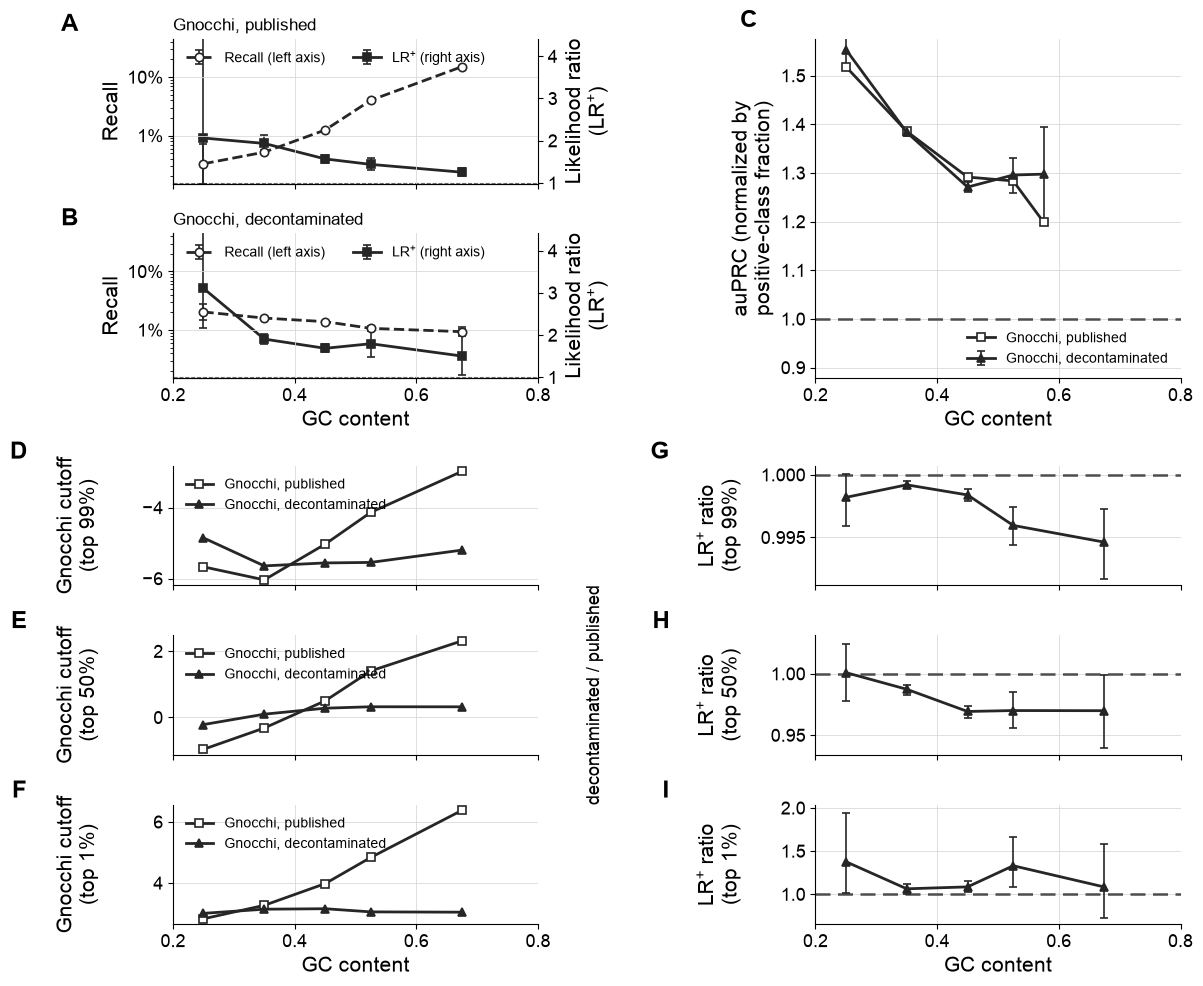

In [19]:
# Guarded, so a run without NEUTRAL_WINDOWS_BED skips these figures rather than dying.
if curves_s8 is not None:
    # NINE PANELS, ONE QUESTION -- what debiasing does to DISCOVERY. Two rows of two slots,
    # a slot being either a stack or one full-height panel:
    #
    #   row 1   A over B      where each score sends its calls    C   no net gain across
    #                                                                 thresholds
    #   row 2   D over E over F                             G over H over I
    #           the cutoff at 99 / 50 / 1%                  the gain at 99 / 50 / 1%
    #
    # THE TWO STACKS ARE ROW-ALIGNED BY CALLING RATE, so each ratio panel sits beside the
    # cutoff it was measured at: D with G at 99%, E with H at 50%, F with I at 1%. They are
    # ordered LEFT TAIL -> MEDIAN -> RIGHT TAIL, which is why the rate descends -- the cutoff
    # isolating the top 99% of a bin sits at z ~ -5, the top 50% IS the median, the top 1% is
    # z ~ +3 to +6 -- so reading down scans the score axis and the two stacks scan it together.
    # Reading down the LEFT stack gives three quantiles of one distribution; reading down the
    # RIGHT stack sweeps C's recall axis, which makes the decomposition a spatial reading.
    #
    # C keeps its full height because auPRC/r spans only ~1.2-1.6 and a wide short panel would
    # flatten the decline that is the point of drawing it. Each ratio panel keeps its OWN y
    # range: at 99% the ratio is pinned near 1.0 by arithmetic, so one shared axis would draw
    # it flat.
    #
    # A LOOKUP FOR THE OLD LETTERS, since captions and git history predating 2026-09-11 use
    # them: old D -> F, old E -> I, old F -> D (same five numbers, read as the cutoff calling
    # the top 99%), old G -> G but RECOMPUTED and its numbers do not carry over; E and H are
    # new.
    fig = plt.figure(figsize=(13.0, 11.5))
    # THE COLUMN GAP IS A SPACER COLUMN rather than a wspace, so its width is stated in
    # inches rather than inferred: 13.0 / (2 + 0.76) gives 4.71 in per panel and 3.58 in of
    # gap, which is what holds A/B's right-hand LR+ label, C's label, and the ratio stack's
    # group label. HEIGHT RATIOS favour row 2, which carries three-panel stacks against row
    # 1's two: 1 : 1.35 on 11.5 in gives each stacked panel ~2.2 in, and a ratio curve with
    # error bars is what suffers first when a row is short.
    gs = fig.add_gridspec(2, 3, width_ratios=[1.0, 0.76, 1.0],
                          height_ratios=[1.0, 1.35], wspace=0.0, hspace=0.22)
    gsAB = gs[0, 0].subgridspec(2, 1, hspace=0.34)
    axA = fig.add_subplot(gsAB[0, 0])
    axB = fig.add_subplot(gsAB[1, 0], sharex=axA)
    axC = fig.add_subplot(gs[0, 2])
    # hspace 0.42 on both stacks: every panel here carries a multi-line rotated y label, and
    # on a third-height row those collide with the panel above at 0.35.
    gsDEF = gs[1, 0].subgridspec(3, 1, hspace=0.42)
    axD = fig.add_subplot(gsDEF[0, 0])
    axE = fig.add_subplot(gsDEF[1, 0], sharex=axD)
    axF = fig.add_subplot(gsDEF[2, 0], sharex=axD)
    gsGHI = gs[1, 2].subgridspec(3, 1, hspace=0.42)
    axG = fig.add_subplot(gsGHI[0, 0])
    axH = fig.add_subplot(gsGHI[1, 0], sharex=axG)
    axI = fig.add_subplot(gsGHI[2, 0], sharex=axG)

    if tm_s8 is not None:
        # A AND B: ONE SCORE EACH, RECALL AND LR+ TOGETHER, at that score's one fixed GLOBAL
        # cutoff. The comparison is WITHIN a panel -- does this score send its calls where a
        # call is worth anything? -- which is why the two scores are two panels rather than
        # two curves. Published's pair runs in OPPOSITE directions: recall climbs 45.7x with
        # GC while LR+ falls, so it calls most where a call is worth least. The retrained
        # score's recall is flat. Both share both y ranges, so the shapes compare by eye.
        #
        # LR+ AND NOT LIFT, because these are cross-bin readings: lift is capped at 1/r and
        # that ceiling falls 7.7x across the axis, while LR+ = TPR/FPR conditions on the true
        # class on both sides and the prevalence cancels. No `deltas`: the object is the
        # relation between two curves for the SAME score, which a published-vs-retrained
        # paired interval does not describe. Wilson bars.
        panels.panel_recall_and_enrichment(axA, tm_s8, "published", show_xlabel=False)
        # sharex drops the duplicate x AXIS but not its tick LABELS, which would otherwise
        # print a second GC scale in the middle of the column.
        axA.tick_params(labelbottom=False)
        panels.panel_recall_and_enrichment(axB, tm_s8, "scored")

    # D, E AND F ARE THREE QUANTILES OF ONE DISTRIBUTION, per GC bin and per score. The
    # argument is in reading them together: if the published cutoff climbs with GC at all
    # three, its bias is a shift of the WHOLE score within a bin rather than a distortion of
    # one tail, which is what licenses reading G, H and I as three views of one ranking. None
    # of the three uses labels.
    #
    # E IS ALSO A CALIBRATION CHECK, and the cheapest in the figure: the cutoff calling the
    # top 50% of a bin IS that bin's median z, and a score whose null is N(0, 1) on these
    # windows has its median near 0 everywhere. Published's drift is the bias stated with no
    # truth set at all.
    if withinbin_99 is not None:
        panels.panel_bin_thresholds(axD, withinbin_99, D.LAX_CALL_RATES[2],
                                    show_xlabel=False)
        axD.tick_params(labelbottom=False)
    if withinbin_50 is not None:
        panels.panel_bin_thresholds(axE, withinbin_50, D.LAX_CALL_RATES[1],
                                    show_xlabel=False)
        axE.tick_params(labelbottom=False)
    if withinbin_s8 is not None:
        panels.panel_bin_thresholds(axF, withinbin_s8, D.LAX_CALL_RATE)

    # C IS THE THRESHOLD-FREE VERDICT and the figure's hinge: I reports a gain at the top 1%,
    # C the same comparison with no threshold at all and it finds a wash. The two are
    # consistent because the scores' precision-recall curves cross, and BOTH have to be shown
    # for that to be sayable. C is also the only panel with no operating point, so the decline
    # it draws cannot be an artefact of where a cutoff sits.
    panels.panel_aupr_by_gc(axC, curves_s8, deltas=deltas_s8)

    # G, H AND I: ONE COMPARISON AT THREE POINTS ON THE RECALL AXIS, the call at z > t and the
    # hit an enhancer throughout. They are RATIOS, not levels: levels invite a cross-bin
    # reading of each score against itself, which is A and B's job, and these ask only whether
    # retraining helps IN a bin. Each `gains_*` must carry metric="lr_pos" -- its `delta` is
    # the ODDS ratio, and a precision ratio is bounded by 1/precision and so not comparable
    # across bins. RECALL IS NOT DRAWN BESIDE ANY OF THEM: with the rate matched within a bin,
    # recall = lift x k at constant k, so it would be a constant rescaling; it earns A and B,
    # where the global cutoff lets k vary 45.7x.
    #
    # WHAT TO EXPECT DOWN THE COLUMN: the magnitudes GROW downward as the calling rate falls,
    # because at 99% both scores' precision is within about a percent of prevalence. So read G
    # for SIGN and H and I for MAGNITUDE -- and 50% is where most of C's area lives, so H is
    # the one that can account for C's wash. data.paired_deltas has the exact statement: the
    # significance carries over and only the numbers do not.
    if gains_wb_99 is not None:
        panels.panel_lr_ratio(axG, gains_wb_99, D.LAX_CALL_RATES[2], show_xlabel=False)
        axG.tick_params(labelbottom=False)
    if gains_wb_50 is not None:
        panels.panel_lr_ratio(axH, gains_wb_50, D.LAX_CALL_RATES[1], show_xlabel=False)
        axH.tick_params(labelbottom=False)
    if gains_wb_s8 is not None:
        panels.panel_lr_ratio(axI, gains_wb_s8, D.LAX_CALL_RATE)

    # ONE GROUP LABEL FOR THE RATIO STACK, carrying the direction of the ratio. Each panel's
    # own y label states only what varies between the three -- the calling rate -- because a
    # rotated label is as tall as its longest line is wide, and at three panels to a row there
    # is no room for both. The direction has to stay somewhere in the artwork, these panels
    # having no legend, so it is stated once for the stack it applies to.
    #
    # PLACED FROM THE AXES' OWN BBOXES rather than at a guessed figure coordinate, so it
    # tracks any later change to the gridspec. The 0.17 offset is measured: it clears the
    # panel letters by 45.8 px and sits 47 px clear of the left column's axes, inside the
    # spacer column.
    if gains_wb_s8 is not None:
        _stack = [ax.get_position() for ax in (axG, axH, axI)]
        fig.text(min(b.x0 for b in _stack) - 0.17,
                 0.5 * (max(b.y1 for b in _stack) + min(b.y0 for b in _stack)),
                 "decontaminated / published", rotation=90, va="center", ha="center",
                 fontsize=panels.AXIS_LABEL_FONTSIZE - 2)

    for ax, lab, x in ((axA, "A", -0.26), (axB, "B", -0.26), (axC, "C", -0.16),
                       # D-I SIT FURTHEST OUT, at -0.40, because their y labels are PINNED
                       # (panel_bin_thresholds says why) and a pinned label cannot be pushed
                       # aside by a letter. -0.40 leaves +20.7 px to the label and +13.3 px
                       # to the tick labels. The letters then overhang the figure's left edge
                       # by 3.5 px, which is harmless: resave_ai saves with
                       # bbox_inches="tight", so the box grows to include them.
                       (axD, "D", -0.40), (axE, "E", -0.40), (axF, "F", -0.40),
                       (axG, "G", -0.40), (axH, "H", -0.40), (axI, "I", -0.40)):
        panels.label_panels((ax,), (lab,), x=x)

    s8_name = f"supp_fig8{config.WINDOW_SET_SUFFIX}"
    written = resave_ai.save_panel(fig, os.path.join(OUTPUT_DIR, s8_name))
    print(f"wrote {', '.join(os.path.basename(p) for p in written)}" if written
          else f"{s8_name}: unchanged, left alone")

In [20]:
# THE THREE OPERATING POINTS SIDE BY SIDE, which is the figure's whole argument and is easier
# to read as a table than off three stacked panels. One comparison, three points on the recall
# axis, ordered as the panels are -- left tail, middle, right tail. A sign that holds across
# the row says the two scores differ the same way everywhere on the ranking; a sign that FLIPS
# says their precision-recall curves cross, and between which columns. The closing lines are
# phrased conditionally on purpose: they say how to READ the table, not what it happens to say.
#
# EXPECT THE MAGNITUDES TO GROW LEFT TO RIGHT by roughly the calling rate: at 99% both scores'
# precision is within about a percent of prevalence, so a ratio there is pinned near 1.0 by
# arithmetic. Read that column for its SIGN and the other two for size. See
# data.paired_deltas.
_cols = [("99%", gains_wb_99), ("50%", gains_wb_50), ("1%", gains_wb_s8)]
if all(g is not None for _, g in _cols):
    print("  LR+ ratio (decontaminated / published), per GC bin, at three calling rates")
    print(f"  {'GC bin':<16}" + "".join(f"{'top ' + n:>28}" for n, _ in _cols))
    fmt = lambda e: (f"{100 * e['delta']:+6.1f}% "
                     f"[{100 * e['ci_lo']:+6.1f},{100 * e['ci_hi']:+6.1f}]"
                     + (" *" if (e['ci_lo'] > 0 or e['ci_hi'] < 0) else "  "))
    rows = [g.sort("mid").to_dicts() for _, g in _cols]
    for entries in zip(*rows):
        first = entries[0]
        print(f"  ({first['lo']:.2f}, {first['hi']:.2f}]{'':<4}"
              + "".join(f"{fmt(e):>28}" for e in entries))
    print()
    for (name, _), col in zip(_cols, rows):
        n_pos = sum(1 for e in col if e["delta"] > 0)
        print(f"  top {name:<4} favours the decontaminated score in {n_pos}/{len(col)} bins")
    print("  a sign that flips between columns => the PR curves cross, and the flip locates\n"
          "  where C's threshold-free wash is averaging a gain against a loss. Signs constant\n"
          "  across every column => the offset lies outside these three points.")

  LR+ ratio (decontaminated / published), per GC bin, at three calling rates
  GC bin                               top 99%                     top 50%                      top 1%
  (0.20, 0.30]         -0.2% [  -0.4,  +0.0]       +0.1% [  -2.2,  +2.4]      +37.7% [  +1.7, +93.8] *
  (0.30, 0.40]         -0.1% [  -0.1,  -0.0] *     -1.3% [  -1.7,  -0.9] *     +6.3% [  +0.8, +12.3] *
  (0.40, 0.50]         -0.2% [  -0.2,  -0.1] *     -3.1% [  -3.6,  -2.6] *     +8.5% [  +2.3, +15.9] *
  (0.50, 0.55]         -0.4% [  -0.6,  -0.3] *     -3.0% [  -4.4,  -1.5] *    +33.0% [  +8.8, +66.4] *
  (0.55, 0.80]         -0.5% [  -0.8,  -0.3] *     -3.0% [  -6.1,  -0.1] *     +8.4% [ -27.5, +58.6]  

  top 99%  favours the decontaminated score in 0/5 bins
  top 50%  favours the decontaminated score in 1/5 bins
  top 1%   favours the decontaminated score in 5/5 bins
  a sign that flips between columns => the PR curves cross, and the flip locates
  where C's threshold-free wash is averaging a gain aga

## Why an analyst should care

> **Debiasing is not mainly about detecting constraint better — that gain is real but
> modest. It is about making the number mean the same thing everywhere.**

Gnocchi is a $z$-score, and a $z$-score promises that a given value means the same departure
from neutral expectation anywhere in the genome. That promise is what licenses attaching a
threshold to it. **Fig. 5F** measures it, with no truth set, and it fails by a factor of 80.

**Concretely.** Two patients, two *de novo* noncoding variants: one in a CpG-island promoter
scoring Gnocchi 4.2, one in an AT-rich distal enhancer scoring 3.8. The analyst keeps the
first and drops the second below threshold. But **14% of GC-rich windows clear 4 against
0.17% of AT-rich ones**, so the second variant is in far rarer company and is the more
surprising observation. The ranking is backwards, and nothing in the score says so. The same
arithmetic puts **44% of all "constrained noncoding" calls in the 7% of the noncoding genome
that is most GC-rich**, where lift is ~1.1 and a call is barely distinguishable from picking
a GC-rich window at random.

**The workaround, if you know the bias.** Convert Gnocchi to a percentile *within GC
stratum*. It is crude, needs only the published table plus GC content, and recovers most of
what retraining achieves — anyone using published Gnocchi today should be doing this rather
than applying one genome-wide cutoff.

**But it has a precondition it cannot verify: you must know which covariates the score varies
with, and know them all.** Stratification removes only the biases already discovered. McHale
et al. tested GC content, BGS and gBGC; Chen et al.'s regional model is fit on thirteen
features across four length scales, most never checked on neutral windows. The patch is
applied per symptom and the list of symptoms is open-ended.

Retraining has no such precondition, because the bias is not a property of GC: it is the
consequence of fitting the regional adjustment on a training population unlike the one the
score is applied to (Fig. 5C–D). Removing the covariate shift removes what it induced,
whatever feature carried it. That is a guarantee about the *mechanism* rather than a list of
symptoms, and it is the reason to prefer it even where the patch would have worked.

*A guarantee about the mechanism is not a measurement.* These figures verify the retrained
score's GC behaviour only; repeating Fig. 5E against BGS and gBGC is the obvious next check,
and is not done here.

In [21]:
# Guarded for the same reason as the cell above.
if curves_s8 is not None:
    # Numbers for Supporting Figure 8's caption. Computed over the bins the panels actually
    # draw -- pr_curves() has already dropped those below the window floor -- so a caption
    # cannot quote a bin the reader cannot see.
    print("truth set: `window overlaps enhancer` (GeneHancer) from "
          f"{os.path.basename(NEUTRAL_WINDOWS_BED)}")
    print(f"positive fraction after balancing: {curves_s8['published']['r']:.4f}")
    for key, c in curves_s8.items():
        print(f"\n{c['display']}: pooled auPRC/r = {c['all']['aupr_norm']:.3f}")
        for e in c["bins"]:
            print(f"  GC ({e['lo']:.2f}, {e['hi']:.2f}]  n = {e['n']:>9,}  "
                  f"auPRC/r = {e['aupr_norm']:.3f}")

    pub, dec = curves_s8["published"]["bins"], curves_s8["scored"]["bins"]
    print("\npanel C, retrained - published, per GC bin (uncertainty in the block below):")
    for a, b in zip(pub, dec):
        print(f"  GC ({a['lo']:.2f}, {a['hi']:.2f}]  {b['aupr_norm'] - a['aupr_norm']:+.3f}")

if deltas_s8 is not None:
    print("\npanel C's error bars: paired gain of the retrained score, unbalanced, 95% CI.")
    print("A bin whose CI excludes 0 is a real difference; P is the bootstrap fraction")
    print("above 0, so it reads as a one-sided posterior-style probability, not a p-value.")
    for r in deltas_s8.iter_rows(named=True):
        star = "  *" if (r["ci_lo"] > 0 or r["ci_hi"] < 0) else "   "
        print(f"  GC ({r['lo']:.2f}, {r['hi']:.2f}]  n = {r['n']:>9,}  "
              f"pos = {r['n_pos']:>8,}  r = {r['r']:.3f}  "
              f"gain = {100 * r['delta']:+6.2f}%  "
              f"[{100 * r['ci_lo']:+6.2f}, {100 * r['ci_hi']:+6.2f}]  "
              f"P(>0) = {r['p_gt0']:.3f}{star}")

if tm_s8 is not None:
    print(f"\npanels A and B. Published held at Gnocchi >= {D.GNOCCHI_THRESHOLD:g} (Chen")
    print("et al.'s own cutoff); the retrained score takes the threshold calling the SAME")
    print("fraction of windows, so precision and recall compare like with like. Unbalanced.")
    print("call_rate uses NO labels, so it is the most robust number here.")
    for key in D.PR_SCORES:
        rows = tm_s8.filter(pl.col("score") == key).sort("mid")
        cr = rows["call_rate"].to_numpy()
        print(f"\n  Gnocchi, {rows['short'][0]} (z >= {rows['threshold_used'][0]:.3f}):  "
              f"calling rate spans {100 * cr.min():.2f}% - {100 * cr.max():.2f}%  "
              f"({cr.max() / cr.min():.2f}x across GC)")
        for r in rows.iter_rows(named=True):
            print(f"    GC ({r['lo']:.2f}, {r['hi']:.2f}]  called {r['n_called']:>7,} "
                  f"({100 * r['call_rate']:6.2f}%)  precision {r['precision']:.3f} "
                  f"[{r['precision_lo']:.3f}, {r['precision_hi']:.3f}]  "
                  f"base rate {r['r']:.3f}  lift {r['lift']:.2f}  "
                  f"recall {100 * r['recall']:6.2f}%")

truth set: `window overlaps enhancer` (GeneHancer) from Supplementary_Data_2.features.constraint_scores.bed
positive fraction after balancing: 0.0833

Gnocchi (published): pooled auPRC/r = 1.321
  GC (0.20, 0.30]  n =    21,862  auPRC/r = 1.518
  GC (0.30, 0.40]  n =   427,169  auPRC/r = 1.385
  GC (0.40, 0.50]  n =   272,867  auPRC/r = 1.292
  GC (0.50, 0.55]  n =    26,838  auPRC/r = 1.284
  GC (0.55, 0.60]  n =     6,217  auPRC/r = 1.199

Gnocchi (decontaminated training set): pooled auPRC/r = 1.341
  GC (0.20, 0.30]  n =    21,862  auPRC/r = 1.554
  GC (0.30, 0.40]  n =   427,169  auPRC/r = 1.383
  GC (0.40, 0.50]  n =   272,867  auPRC/r = 1.271
  GC (0.50, 0.55]  n =    26,838  auPRC/r = 1.296
  GC (0.55, 0.60]  n =     6,217  auPRC/r = 1.298

panel C, retrained - published, per GC bin (uncertainty in the block below):
  GC (0.20, 0.30]  +0.035
  GC (0.30, 0.40]  -0.002
  GC (0.40, 0.50]  -0.021
  GC (0.50, 0.55]  +0.012
  GC (0.55, 0.60]  +0.099

panel C's error bars: paired gain

## Numbers for the caption

Everything quoted in the caption should come from here, not from memory.

In [22]:
# Every number below is computed over the bins the panels actually plot -- the same
# min_n floor and, for panel C, the same x range. Otherwise a caption can quote a bin
# the reader cannot see.
print(f"panel A: {df_a.height:,} windows after joint z filtering, mean GC {gc_mean:.3f}")
for label, name in [("step1", "context-only (r = 1)"), ("step2", "Gnocchi as published")]:
    print(f"  mean |rank - 0.5|  {name:<34} {D.rank_bias(binned_a, label, MIN_N_WINDOWS):.3f}")
if binned_dr is not None:
    print(f"  mean |rank - 0.5|  {'depletion rank':<34} "
          f"{D.rank_bias(binned_dr, 'dr', MIN_N_WINDOWS):.3f}")

b = binned_b.filter(pl.col("n") >= MIN_N_WINDOWS)
print(f"\npanel B: r_non spans {b['r_non'].min():.3f}-{b['r_non'].max():.3f}; "
      f"r_CpG spans {b['r_cpg'].min():.3f}-{b['r_cpg'].max():.3f}; "
      f"counterfactual spans {b['r_counterfactual'].min():.3f}-"
      f"{b['r_counterfactual'].max():.3f}")
print(f"  CpG share of expected counts rises {b['pi_cpg'].min():.3f} -> {b['pi_cpg'].max():.3f}")

# Restricted to the plotted x range as well: the bins below it are almost entirely
# QC-failing sequence, so an unrestricted min() would report an analyzed fraction of 0.00
# from a bin the panel does not draw.
c = comp.filter((pl.col("n_total") >= MIN_N_SITES)
                & pl.col("gc_mid").is_between(*XRANGE)).sort("gc_mid")
print(f"\npanel C: {int(c['n_total'].sum()):,} non-CpG training sites in the plotted "
      f"range; scored-population fraction {c['frac_scored'][0]:.2f} at GC "
      f"{c['gc_mid'][0]:.2f} -> {c['frac_scored'][-1]:.2f} at GC {c['gc_mid'][-1]:.2f}")

print("\npanel D: empirical P(DNM), max / min ratio within each population")
for pop, tab in binned_d.items():
    e = tab["empirical_prop"]
    print(f"  {pop:<12} {e.max() / e.min():.2f}x   "
          f"(fitted {tab['mean_pred'].max() / tab['mean_pred'].min():.2f}x)")

print(f"\npanel E: {df_e.height:,} windows after joint z filtering")
for label, name in [("step1", "context-only (r = 1)"),
                    ("step2", "Gnocchi as published"),
                    ("scored", "Gnocchi, retrained on the filtered training set"),
                    ("full_refit", "  control: refit on the full training set"),
                    ("sizematched", "  control: size-matched random subsample")]:
    print(f"  mean |rank - 0.5|  {name:<44} {D.rank_bias(binned_e, label, MIN_N_WINDOWS):.3f}")

panel A: 692,348 windows after joint z filtering, mean GC 0.393
  mean |rank - 0.5|  context-only (r = 1)               0.046
  mean |rank - 0.5|  Gnocchi as published               0.168
  mean |rank - 0.5|  depletion rank                     0.096

panel B: r_non spans 0.960-1.450; r_CpG spans 0.997-1.014; counterfactual spans 1.000-1.004
  CpG share of expected counts rises 0.038 -> 0.264

panel C: 4,367,225 non-CpG training sites in the plotted range; scored-population fraction 0.00 at GC 0.22 -> 0.00 at GC 0.70

panel D: empirical P(DNM), max / min ratio within each population
  full         2.45x   (fitted 2.27x)
  scored       1.60x   (fitted 1.09x)

panel E: 692,325 windows after joint z filtering
  mean |rank - 0.5|  context-only (r = 1)                         0.046
  mean |rank - 0.5|  Gnocchi as published                         0.168
  mean |rank - 0.5|  Gnocchi, retrained on the filtered training set 0.026
  mean |rank - 0.5|    control: refit on the full training set    

## Caveats that belong in the caption

* **Panel D is in-sample.** The retrained model is fit on training sites in the analyzed
  windows and scored against the labels of those same sites. Panel E is the
  out-of-sample confirmation: it is measured on gnomAD polymorphism counts, which the
  DNM model never sees. A held-out DNM split would make panel D airtight; it has not
  been run.
* **The depletion-rank curve comes from a different window set** (Halldorsson windows, a
  different window size) than the two Gnocchi curves. They are not joined; each is
  ranked within itself, and each is binned on its own GC edges. Halldorsson's windows
  also **overlap**, so no error bar is drawn for that curve: the within-bin windows are
  not independent, which the shared `std / sqrt(n)` assumes. It reads last in the
  legend for the same reason — it is the external comparison, not a third Gnocchi curve.
* **This run used McHale et al.'s 693,270 windows**, and the caption says so.
  `NEUTRAL_WINDOWS_BED` unset would mean the 1,843,559 noncoding + `pass_qc` +
  autosome/PAR windows this repo builds from the bucket; set, as here, it means their
  693,270, taken from their file with none of those three filters applied on top —
  theirs is the definition, so it enters whole (`windows.build_window_table`). Either
  way it is one definition applied consistently: every panel, the population the
  retrained model is fit on, and panel C's bottom band, which is membership in that
  population rather than a re-derivation of its filters. The gap between the two is
  2.66x and is not only enhancer-overlapping windows — their assembly-gap,
  ENCODE-exclude and low-coverage exclusions are in it too — so a result that holds on
  only one of them is a result about the window definition.

  Switching recomputes everything: A, B and E directly, D through the `scored` refit
  (`sizematched` is no longer drawn there, but panel E still reports it), and C through
  both its bottom band and the shared GC bin edges,
  which span the window set's own GC range. Two operational costs. The refits must be
  rerun (`config.check()` refuses one stamped with a different value, naming the
  command), and since they are keyed by population alone, one window set's refits
  overwrite the other's — switching back means rerunning again, ~6 min each. The panel-C
  and CpG caches in `output/` are keyed by a fingerprint of the edges and the window
  set, so those two do coexist.

## Refresh the Illustrator assembly

The manuscript figure is assembled in `fig5.ai` from the panel PDFs above, as **links**,
and `fig5.png` is exported from that assembly — the readable copy, since an .ai renders as
nothing on GitHub. Any panel this run rewrote therefore leaves both stale, and the repo --
which tracks them and is the source of truth for both -- would carry an assembly that
disagrees with its own panels until Illustrator reloads the links, the document is saved,
and the PNG is exported again.

The cell below does all three, so a notebook run ends with everything in step. It relinks
only the panels whose content the .ai does not already hold — judged by hash against
`fig5.ai.links.json`, not by mtime — and prints each one: relinking preserves a placed
item's frame rather than its aspect ratio, so a panel whose bounding box moved is worth a
look. A run that changed no artwork has nothing to relink, because `save()` above left
those files untouched. Nothing here is required to build the figure -- without Illustrator, or without the
.ai, it prints a notice and moves on -- and the neutral window set's assembly (`fig5.neutral.ai`)
does not exist until someone builds it, which is a notice too. `fig5/resave_ai.py` is the
same code as a command; `-suffix .neutral` picks the other assembly.

In [23]:
_ = resave_ai.refresh(quiet_if_absent=True,        # the return code is for the shell, not here
                      suffix=config.WINDOW_SET_SUFFIX)

2 panel PDF(s) newer than what fig5.neutral.ai was saved against: fig5B.neutral.pdf, supp_fig8.neutral.pdf
could not reach Illustrator, so fig5.neutral.ai is still stale:
osascript not found, so Illustrator cannot be reached: this step is macOS-only. Copy fig5/output/*.pdf back to the Mac and assemble there (fig5/RUNBOOK.md step 8).
